# # Predicción de Producción de Petróleo no convencional en Vaca Muerta  - Preparacion de Datos


# 0) Vision General de la Preparación de datos

Esta notebook integra, filtra y limpia los datos públicos de SESCO para producir **`datos_modelo.csv`** — el dataset final, a nivel pozo-mes, que consume la notebook de modelado (`transformer.ipynb`) para entrenar el Transformer que pronostica producción de petróleo a 12 meses por pozo.

## Fuentes de datos

- **Pozos** (`Capítulo IV - Pozos`): registro maestro de pozos — una fila por pozo, con atributos de identificación, ubicación y clasificación (cuenca, formación, tipo de pozo, estado, profundidad, geometría).
- **Producción** (`Producción de Pozos de Gas y Petróleo No Convencional`): serie histórica de producción mensual — una fila por pozo y por mes, con los volúmenes producidos/inyectados (incluida `prod_pet`, la variable objetivo) y el estado operativo mensual (`tipoestado`).
- **Datos de fractura** (`Adjunto IV`): parámetros de completación hidráulica — un registro por evento de fractura, con longitud de rama horizontal, cantidad de etapas, arena y agua bombeadas, presión, etc. Son estáticos en el tiempo por pozo, y se usan como regresores del modelo.

## Estructura de la notebook

- **1) Carga y entendimiento general de datos**: exploración inicial de las 3 fuentes (Pozos, Producción, Datos de fractura).
- **2) Filtrado de pozos, verificación de datos e imputaciones**: filtro categórico inicial más exclusiones validadas empíricamente (pozos multifractura, sin datos de fractura, "atípicos", con huecos en su historia), chequeos de calidad e imputaciones sobre cada fuente, y el join final de las 3 tablas.
- **3) Análisis de historia de producción y armado de ventanas y splits Train/Val/Test**: cortes de calendario fijos y elegibilidad de cada pozo por split (usando el módulo `datasets.py`), con el descarte final y guardado de **`datos_modelo.csv`**.
- **4) Visualización de series de producción**: gráficos exploratorios de las curvas de producción.
- **5) Análisis de la variable target (`prod_pet`)**: distribución, heterogeneidad de escala entre pozos y producción nula — justifican la transformación (`log1p` + normalización por pozo) antes de entrenar.
- **6) Análisis de variables regresoras**: distribución de los parámetros de completación y coordenadas, para decidir su normalización.

## Módulo `datasets.py`

Concentra la lógica de armado de ventanas y splits que reutilizan tanto esta notebook como la de modelado: cálculo de los cortes de calendario de Train/Val/Test, elegibilidad de cada pozo por split, filtrado de pozos por continuidad/paradas de producción, generación de las ventanas de entrada/target, normalización de `prod_pet` (`log1p` + z-score por pozo, ajustada solo con datos de Train) y el `Dataset`/`DataModule` de PyTorch que finalmente alimenta al modelo.


## 1) Carga y entendimiento General de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
from pathlib import Path


In [2]:
df_pozos = pd.read_csv('./data/capitulo-iv-pozos.csv')
df_prod = pd.read_csv('./data/produccin-de-pozos-de-gas-y-petrleo-no-convencional.csv')

df_frac = pd.read_csv('./data/datos-de-fractura-de-pozos-de-hidrocarburos-adjunto-iv-actualizacion-diaria.csv')

print(f"df_pozos     : {df_pozos.shape[0]:>8,} filas  x {df_pozos.shape[1]} columnas")
print(f"df_prod : {df_prod.shape[0]:>8,} filas  x {df_prod.shape[1]} columnas")

print(f"df_frac : {df_frac.shape[0]:>8,} filas  x {df_frac.shape[1]} columnas")



df_pozos     :   85,611 filas  x 26 columnas
df_prod :  410,945 filas  x 40 columnas
df_frac :    4,806 filas  x 30 columnas


### 1.1) Pozos

Esta tabla es el **registro maestro de pozos**: contiene una fila por cada pozo (`idpozo`) con sus atributos estáticos de identificación, ubicación y clasificación (cuenca, formación, tipo de pozo, estado actual, etc). Se corresponde con el recurso [Capítulo IV - Pozos](http://datos.energia.gob.ar/dataset/produccion-de-petroleo-y-gas-por-pozo/archivo/cb5c0f04-7835-45cd-b982-3e25ca7d7751)  del dataset público [Producción de Petróleo y Gas por Pozo](http://datos.energia.gob.ar/dataset/produccion-de-petroleo-y-gas-por-pozo) del SESCO (Sistema Estadístico de la Subsecretaría de Combustibles)


#### Definición del filtro inicial para el Universo de Pozos

El objetivo del TP es predecir la curva de producción mensual de petróleo a 12 meses (t+1 a t+12) para pozos no convencionales de la formación Vaca Muerta, a nivel de pozo individual, utilizando datos públicos del SESCO. En función de ese objetivo, un _filtro inicial_ para delimitar el universo de análisis es el siguiente:

- **cuenca == "NEUQUINA"**: Vaca Muerta es una formación geológica propia de la cuenca Neuquina; esta condición fija el ámbito geográfico del análisis.
- **tipo_recurso == "NO CONVENCIONAL"**: el TP se enfoca en producción no convencional (shale), excluyendo pozos convencionales que responden a una dinámica de producción distinta.
- **formacion == "vaca muerta"**: acota el universo específicamente a la formación productiva definida en el alcance del trabajo.
- **tipopozo == "Petrolífero"**: la variable objetivo es producción de petróleo (`prod_pet`); se excluyen pozos gasíferos u otras clasificaciones cuyo producto principal no es petróleo.
- **clasificacion == "EXPLOTACION"**: se seleccionan pozos de explotación (producción a escala) y no de exploración/avanzada, cuyo comportamiento productivo no es representativo del fenómeno que se busca modelar.
- **tipoestado == "Extracción Efectiva"**: el pozo debe estar activo y en extracción real al momento de la foto de `df_pozos`, descartando pozos parados, abandonados o aún no habilitados.

En las celdas siguientes se explora el conjunto de valores posibles de estos atributos en `df_pozos`, para confirmar los valores utilizados

In [3]:
df_pozos.info()

print("Filas duplicadas:", df_pozos.duplicated().sum())
print("Pozos duplicados:", df_pozos.duplicated(subset=["idpozo"]).sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85611 entries, 0 to 85610
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sigla                    85611 non-null  object 
 1   idpozo                   85611 non-null  int64  
 2   area                     85611 non-null  object 
 3   cod_area                 85611 non-null  object 
 4   empresa                  84647 non-null  object 
 5   yacimiento               85611 non-null  object 
 6   cod_yacimiento           85611 non-null  object 
 7   formacion                82796 non-null  object 
 8   cuenca                   85611 non-null  object 
 9   provincia                85611 non-null  object 
 10  cota                     85611 non-null  float64
 11  profundidad              85611 non-null  float64
 12  clasificacion            85611 non-null  object 
 13  subclasificacion         85611 non-null  object 
 14  tipo_recurso          

In [4]:
display(df_pozos.sample(2, random_state=37).T)

,8223,82904
sigla,CFP.Ch.SJ-153,TPT.Nq.FP-1058(h)
idpozo,39523,164250
area,KM. 8,FORTIN DE PIEDRA
cod_area,KO8,FOR
empresa,"CRI HOLDING, INC.",TECPETROL S.A.
yacimiento,KM. 8,FORTIN DE PIEDRA
cod_yacimiento,KM8,FOR
formacion,salamanca,vaca muerta
cuenca,GOLFO SAN JORGE,NEUQUINA
provincia,Chubut,Neuquén


In [5]:
atributos = ["tipo_recurso", "cuenca", "formacion", "tipopozo", "tipoestado", "clasificacion"]
VALORES_POR_LINEA = 5
INDENTACION = " " * 15

for atributo in atributos:
    valores = pd.Series(df_pozos[atributo].unique()).sort_values().astype(str).tolist()
    bloques = [valores[i:i + VALORES_POR_LINEA] for i in range(0, len(valores), VALORES_POR_LINEA)]

    print(f"{atributo}: {', '.join(bloques[0])}")
    for bloque in bloques[1:]:
        print(f"{INDENTACION}{', '.join(bloque)}")
    # print()


tipo_recurso: CONVENCIONAL, NO CONVENCIONAL, NO DISCRIMINADO, No informado, SIN RESERVORIO
cuenca: AUSTRAL, CAÑADON ASFALTO, CUYANA, GENERAL LEVALLE, GOLFO SAN JORGE
               LOS BOLSONES, NEUQUINA, NORESTE, NOROESTE, ÑIRIHUAU
formacion: ANITA, Agua de la Piedra, Piedra Clavada, Río Seco, agrio
               bajada colorada, bajo barreal, barda negra, barrancas, basamento
               cacheuta, castillo, catriel, cañadon seco, centenario
               chachao, challacó, choiyoi, comodoro rivadavia, conglomerado rojo inferior
               divisadero largo, el trebol, formación improductiva, glauconitico , grupo chubut
               grupo neuquén, huamampampa, huitrín, icla, iquiri
               la manga, la pilona, la tigra, lajas, las cabras
               las peñas, loma montosa, lonco trapial , loncoche, los molles
               los monos, lotena, magallanes, maiz gordo, meseta espinosa
               mina el carmen, mulichinco, neocomiano, palermo aike, palmar largo
 

### 1.2) Producción

Esta tabla es la **serie histórica de producción mensual por pozo**: a diferencia de `df_pozos` (una fila por pozo), tiene una fila con el volúmen de petróleo producido por pozo en cada mes. Además, cada fila repite de forma varios atributos "maestros" del pozo (empresa, cuenca, formación, clasificación, tipo de pozo, coordenadas). Se corresponde con el recurso [Producción de Pozos de Gas y Petróleo No Convencional](http://datos.energia.gob.ar/dataset/c846e79c-026c-4040-897f-1ad3543b407c/archivo/b5b58cdc-9e07-41f9-b392-fb9ec68b0725) del mismo datset que el indicado para **Pozos** 

#### Atributos clave

Antes de avanzar con el análisis, se describen los atributos clave que se van a utilizar en el resto del trabajo:

- **anio** / **mes**: año y mes calendario del registro de producción. Cada combinación de `idpozo`, `anio` y `mes` identifica una observación mensual única dentro de la historia productiva de un pozo, y define la granularidad temporal de la serie.
- **idpozo**: identificador único del pozo. Es la clave de agrupamiento y de join entre tablas, y define la unidad de análisis del TP.
- **prod_pet**: producción mensual de petróleo (m³). Es la variable objetivo del TP: la serie que el modelo debe pronosticar a 12 meses (t+1 a t+12).
- **coordenadax** / **coordenaday**: coordenadas de ubicación del pozo (longitud y latitud respectivamente). Se utilizan estas columnas en lugar del campo `geojson` de `df_pozos` porque como se verá más adelante tienen la misma información
- **tipoestado_prod**: estado operativo del pozo en cada mes (`Extracción Efectiva`, `Parado Transitoriamente`, `Abandonado`, etc.). 



In [6]:
df_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410945 entries, 0 to 410944
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               410945 non-null  object 
 1   anio                    410945 non-null  int64  
 2   mes                     410945 non-null  int64  
 3   idpozo                  410945 non-null  int64  
 4   prod_pet                410945 non-null  float64
 5   prod_gas                410945 non-null  float64
 6   prod_agua               410945 non-null  float64
 7   iny_agua                410945 non-null  float64
 8   iny_gas                 410945 non-null  float64
 9   iny_co2                 410945 non-null  float64
 10  iny_otro                410945 non-null  float64
 11  tef                     410945 non-null  float64
 12  vida_util               8723 non-null    float64
 13  tipoextraccion          410335 non-null  object 
 14  tipoestado          

In [7]:
display(df_prod.sample(2, random_state=37).T)

,176924,56827
idempresa,YPF,YPF
anio,2022,2024
mes,10,3
idpozo,156904,164028
prod_pet,2.94,1220.37
prod_gas,31.34,179.57
prod_agua,0.57,0.0
iny_agua,0.0,0.0
iny_gas,0.0,0.0
iny_co2,0.0,0.0


#### Comparacion geolocalización df_pozos vs. df_prod

Antes de definir qué campo de ubicación usar en el dataset final, se comparan las coordenadas extraídas de `geojson` (`df_pozos`) contra `coordenadax`/`coordenaday` (`df_prod`)

**Conclusión:** ambas fuentes representan la misma ubicación por pozo → se va a usar `coordenadax`/`coordenaday` de `df_prod` como fuente de geolocalización que ya está parseada


In [8]:
import json
import random

# 1. Ver tipo de dato y primeras entradas crudas
print("Tipo geojson:", type(df_pozos['geojson'].iloc[0]))
print("Tipo geom:   ", type(df_pozos['geom'].iloc[0]))
print()

# 2. Ver si alguno está vacío o es None/NaN/string vacío
print("geojson vacíos:", (df_pozos['geojson'].isna() | (df_pozos['geojson'] == '')).sum())
print("geom vacíos:   ", (df_pozos['geom'].isna() | (df_pozos['geom'] == '')).sum())
print()


# Imprimir N registros al azar — ver el contenido crudo
N = 2
muestra = df_pozos[['sigla', 'geojson', 'geom']].sample(N, random_state=42)
for _, row in muestra.iterrows():
    print(f"=== Pozo: {row['sigla']} ===")
    print("-- geojson crudo --")
    print(row['geojson'])
    print("-- geom crudo --")
    print(row['geom'])
    print()

Tipo geojson: <class 'str'>
Tipo geom:    <class 'str'>

geojson vacíos: 0
geom vacíos:    0

=== Pozo: APA.RN.LR-1036 ===
-- geojson crudo --
{"type":"Point","coordinates":[-67.875576240000001,-38.175665940000002]}
-- geom crudo --
0101000020E610000019FDEC7009F850C01AA9B5387C1643C0

=== Pozo: YPF.SC.CS-321 ===
-- geojson crudo --
{"type":"Point","coordinates":[-67.728877909999994,-46.581313420000001]}
-- geom crudo --
0101000020E6100000848E88EFA5EE50C01ED0677A684A47C0



In [9]:
# ── Comparación específica: geolocalización (geojson vs coordenadax/coordenaday) ──
# geojson en df_pozos viene como {"type":"Point","coordinates":[lon, lat]}
# (RFC 7946: primero longitud, después latitud — se confirma con el ejemplo
# dado: lon≈-68.27 / lat≈-38.92, coherente con la cuenca Neuquina).

import json
import numpy as np

def _coords_desde_geojson(valor):
    try:
        obj = json.loads(valor)
        lon, lat = obj["coordinates"][0], obj["coordinates"][1]
        return float(lon), float(lat)
    except (TypeError, ValueError, KeyError, IndexError, json.JSONDecodeError):
        return np.nan, np.nan


def comparar_geolocalizacion(df_pozos, df_prod, tolerancia=1e-4):
    """
    tolerancia en grados decimales (1e-4 ≈ 11 m en esta latitud).
    """
    geo = df_pozos[["idpozo", "geojson"]].copy()
    geo[["lon_geojson", "lat_geojson"]] = geo["geojson"].apply(lambda v: pd.Series(_coords_desde_geojson(v)))

    # coordenadax/coordenaday están en df_prod, repetidas por mes -> 1 valor por pozo.
    # nunique() detecta si hay más de un valor distinto por pozo (inconsistencia);
    # first() se queda con un valor representativo para la comparación.
    coords_prod = df_prod.groupby("idpozo")[["coordenadax", "coordenaday"]].agg(["nunique", "first"])
    coords_prod.columns = ["_".join(col) for col in coords_prod.columns]

    inconsistentes = coords_prod[
        (coords_prod["coordenadax_nunique"] > 1) | (coords_prod["coordenaday_nunique"] > 1)
    ]

    coords_prod = coords_prod.rename(
        columns={"coordenadax_first": "coordenadax", "coordenaday_first": "coordenaday"}
    )

    detalle = geo.merge(coords_prod[["coordenadax", "coordenaday"]], on="idpozo", how="inner")

    detalle["dif_geojson"] = np.sqrt(
        (detalle["lon_geojson"] - detalle["coordenadax"]) ** 2 +
        (detalle["lat_geojson"] - detalle["coordenaday"]) ** 2
    )
    detalle["geojson_coincide"] = detalle["dif_geojson"] <= tolerancia

    n = len(detalle)
    resumen = pd.DataFrame([{
        "pozos_comparados": n,
        "coinciden_con_coordenadax_y": int(detalle["geojson_coincide"].sum()),
        "pct_coincide": round(detalle["geojson_coincide"].mean() * 100, 1),
        "diferencia_max": detalle["dif_geojson"].max(),
        "diferencia_media": detalle["dif_geojson"].mean(),
    }])

    return resumen, detalle, inconsistentes


resumen_geo, detalle_geo, pozos_coord_inconsistente = comparar_geolocalizacion(df_pozos, df_prod)

print(f"Pozos con más de un valor de coordenadax/coordenaday en df_prod: {len(pozos_coord_inconsistente)}\n")
print(resumen_geo.to_string(index=False))

print("\nEjemplos de mayor discrepancia geojson vs. coordenadax/coordenaday:")
display(
    detalle_geo[~detalle_geo["geojson_coincide"]]
    .sort_values("dif_geojson", ascending=False)
    [["idpozo", "lon_geojson", "lat_geojson", "coordenadax", "coordenaday", "dif_geojson"]]
    .head(10)
)


Pozos con más de un valor de coordenadax/coordenaday en df_prod: 0

 pozos_comparados  coinciden_con_coordenadax_y  pct_coincide  diferencia_max  diferencia_media
             4995                         4995         100.0             0.0               0.0

Ejemplos de mayor discrepancia geojson vs. coordenadax/coordenaday:


,idpozo,lon_geojson,lat_geojson,coordenadax,coordenaday,dif_geojson


### 1.3) Datos de fractura de Pozos

Esta tabla contiene los **parámetros de completación hidráulica** de cada pozo: un registro por evento de fractura, con las variables de diseño y ejecución del trabajo de estimulación (longitud de rama horizontal, cantidad de etapas, volumen de arena y agua bombeados, presión, potencia de equipos) y sus fechas de inicio/fin. A diferencia de `df_pozos` y `df_prod`, estos atributos son estáticos en el tiempo por pozo — no varían mes a mes — por lo que van a actuar como **regresores** del modelo: información conocida de antemano que se repite en cada paso temporal de la serie de producción. Se corresponde con el recurso [Datos de fractura de pozos de hidrocarburos (Adjunto IV)](http://datos.energia.gob.ar/dataset/datos-de-fractura-de-pozos-adjunto-iv/archivo/2280ad92-6ed3-403e-a095-50139863ab0d) del SESCO (Secretaría de Energía de la Nación).

#### Atributos candidatos a regresores

Como primera iteración del modelo, se preseleccionan los siguientes atributos por su potencial predictivo en la producción de un pozo no convencional. Esta selección es preliminar, más adelante se buscará validar y refinar con referentes del dominio:

- **longitud_rama_horizontal_m**: longitud de la rama horizontal perforada (m). A mayor longitud, mayor superficie de contacto con la roca reservorio, y en general mayor producción potencial.
- **cantidad_fracturas**: cantidad de etapas de fractura ejecutadas. Más etapas implican mayor estimulación y contacto efectivo con el reservorio a lo largo de la rama horizontal.
- **arena_bombeada_nacional_tn** / **arena_bombeada_importada_tn**: toneladas de arena (proppant) bombeadas. El proppant mantiene abiertas las fracturas generadas y determina la conductividad del sistema de fracturas.
- **agua_inyectada_m3**: volumen de agua inyectada durante la fractura (m³). Es un proxy de la intensidad global del tratamiento de estimulación.
- **presion_maxima_psi**: presión máxima alcanzada durante el bombeo (psi). Refleja tanto el diseño del tratamiento como características del reservorio (ej. esfuerzos in-situ).

In [10]:
# ── Exploración df_frac ──────────────────────────────────────────────────────

# 1. Estructura general
print(df_frac.info())

# 3. Muestra transpuesta (3 filas, fácil de leer)
display(df_frac.sample(2, random_state=37).T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4806 entries, 0 to 4805
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_base_fractura_adjiv        4806 non-null   int64  
 1   idpozo                        4806 non-null   int64  
 2   sigla                         4806 non-null   object 
 3   cuenca                        4806 non-null   object 
 4   areapermisoconcesion          4806 non-null   object 
 5   yacimiento                    4806 non-null   object 
 6   formacion_productiva          4806 non-null   object 
 7   tipo_reservorio               4771 non-null   object 
 8   subtipo_reservorio            3832 non-null   object 
 9   longitud_rama_horizontal_m    4806 non-null   float64
 10  cantidad_fracturas            4806 non-null   int64  
 11  tipo_terminacion              4806 non-null   object 
 12  arena_bombeada_nacional_tn    4806 non-null   float64
 13  are

,2852,2530
id_base_fractura_adjiv,3482,3138
idpozo,162576,161790
sigla,YPF.Nq.RN-2052(d),APS.Nq.Sa-1176
cuenca,NEUQUINA,NEUQUINA
areapermisoconcesion,RIO NEUQUEN,AGUA DEL CAJON
yacimiento,RIO NEUQUEN,EL SALITRAL
formacion_productiva,punta rosada,lajas
tipo_reservorio,NO CONVENCIONAL,CONVENCIONAL
subtipo_reservorio,TIGHT,NaN
longitud_rama_horizontal_m,0.0,0.0


## 2) Filtrado de pozos, verificación de datos e imputaciones

- Como se anticipó en la sección "1.1) Pozos", se aplicará a continuación el _filtro inicial_ asociado al alcance de este Trabajo Práctico. Este filtro inicial es de carácter categórico (cuenca, tipo de recurso, formación, tipo de pozo, clasificación y estado) y define el universo de pozos elegibles en base a sus atributos estructurales en `df_pozos`. 
- Más adelante se va a aplicar un _segundo filtro_ , esta vez sobre la propia serie de producción (`df_prod`), en base a la longitud mínima de historia disponible y otras caracterísiticas.

In [11]:
# df_pozos_nc -> pozos "No convencionales"
df_pozos_nc = df_pozos[
    (df_pozos["cuenca"] == "NEUQUINA") &
    (df_pozos["tipo_recurso"] == "NO CONVENCIONAL") &
     (df_pozos["formacion"] == "vaca muerta") &
     (df_pozos["tipopozo"] == "Petrolífero") &
     (df_pozos["clasificacion"] == "EXPLOTACION") &
     (df_pozos["tipoestado"] == "Extracción Efectiva")
].copy()

print(f"Filas originales : {len(df_pozos):>8,}")
print(f"Filas filtradas  : {len(df_pozos_nc):>8,}")
print(f"Pozos únicos     : {df_pozos_nc['idpozo'].nunique():>8,}")

Filas originales :   85,611
Filas filtradas  :    2,062
Pozos únicos     :    2,062


#### 2.1) Pozos y fracturas - Descarte de pozos sin fractura o multi-fractura

- En las próximas celdas se verfica qué proporción de los pozos no convencionales (`df_pozos_nc`) tiene datos de fractura en `df_frac`, identificando los pozos sin registro (163, ~8%) y con más de un evento (5, ~0,3%). 
- Ambos casos se descartan en este primer entregable: se requiere exactamente una completación por pozo para usar sus parámetros como regresor estático, sin ambigüedad de qué evento usar ni datos faltantes que imputar. 
- Es una simplificación de alcance y para el Trabajo Final se podría evaluar imputar los parámetros faltantes (ej. mediana condicionada por yacimiento y año de perforación) en vez de descartar los pozos sin fractura.

In [12]:
# ── Diagnóstico: relación df_pozos_nc ↔ df_frac ─────────────────────────────

pozos_nc_ids = set(df_pozos_nc['idpozo'])

# 1. Cuántos pozos NC tienen al menos un registro en df_frac
frac_nc = df_frac[df_frac['idpozo'].isin(pozos_nc_ids)].copy()
pozos_con_frac_ids = set(frac_nc['idpozo'].unique())
pozos_sin_frac_ids = pozos_nc_ids - pozos_con_frac_ids

print(f"Pozos NC totales          : {len(pozos_nc_ids):>6,}")
print(f"Pozos NC con fractura     : {len(pozos_con_frac_ids):>6,}  ({len(pozos_con_frac_ids)/len(pozos_nc_ids)*100:.1f}%)")
print(f"Pozos NC sin fractura     : {len(pozos_sin_frac_ids):>6,}  ({len(pozos_sin_frac_ids)/len(pozos_nc_ids)*100:.1f}%)")
print()

# 2. Distribución de fracturas por pozo (¿hay pozos con más de una?)
fracs_por_pozo = frac_nc.groupby('idpozo').size().value_counts().sort_index()
print("Registros de fractura por pozo:")
for n_fracs, cantidad_pozos in fracs_por_pozo.items():
    print(f"  {n_fracs} fractura(s)  →  {cantidad_pozos:,} pozos")
print()

# 3. Ver ejemplos de pozos con más de una fractura
pozos_multifrac = frac_nc.groupby('idpozo').size()
pozos_multifrac = pozos_multifrac[pozos_multifrac > 1].index.tolist()

print(f"Pozos con más de 1 fractura: {len(pozos_multifrac)}\n")

display(frac_nc[frac_nc['idpozo'].isin(pozos_multifrac)][
    ['sigla', 'idpozo', 'fecha_inicio_fractura', 'fecha_fin_fractura',
     'longitud_rama_horizontal_m', 'cantidad_fracturas', 'agua_inyectada_m3']
].sort_values(['idpozo', 'fecha_inicio_fractura']))

# ── Descarte de pozos sin fractura o con más de un evento de fractura ───────

pozos_antes = df_pozos_nc["idpozo"].nunique()

pozos_a_excluir = pozos_sin_frac_ids | set(pozos_multifrac)
df_pozos_nc = df_pozos_nc[~df_pozos_nc["idpozo"].isin(pozos_a_excluir)].copy()

pozos_despues = df_pozos_nc["idpozo"].nunique()

print(f"\nPozos NC antes de filtrar             : {pozos_antes:>6,}")
print(f"  Excluidos por no tener fractura      : {len(pozos_sin_frac_ids):>6,}")
print(f"  Excluidos por tener multifractura    : {len(pozos_multifrac):>6,}")
print(f"Pozos NC después de filtrar (1 fractura): {pozos_despues:>6,}")


Pozos NC totales          :  2,062
Pozos NC con fractura     :  1,899  (92.1%)
Pozos NC sin fractura     :    163  (7.9%)

Registros de fractura por pozo:
  1 fractura(s)  →  1,894 pozos
  2 fractura(s)  →  5 pozos

Pozos con más de 1 fractura: 5



,sigla,idpozo,fecha_inicio_fractura,fecha_fin_fractura,longitud_rama_horizontal_m,cantidad_fracturas,agua_inyectada_m3
2601,VIS.Nq.BPO-2391(h),161998,2020-12-10,2021-01-08,2708.3,56,90076.49
4689,VIS.Nq.BPO-2391(h),161998,2026-01-24,2026-02-09,1951.0,34,54817.32
2603,VIS.Nq.BPO-2392(h),161999,2020-12-11,2021-01-08,2611.3,54,87231.79
4690,VIS.Nq.BPO-2392(h),161999,2026-01-24,2026-02-11,2196.0,38,58393.02
2602,VIS.Nq.BPO-2393(h),162000,2020-12-10,2021-01-08,2708.3,56,91197.44
4691,VIS.Nq.BPO-2393(h),162000,2026-01-24,2026-02-11,2147.0,37,60535.88
2600,VIS.Nq.BPO-2394(h),162001,2020-12-10,2021-01-07,2756.8,57,92712.68
4692,VIS.Nq.BPO-2394(h),162001,2026-01-25,2026-02-11,2162.0,31,49389.33
2702,XOM.Nq.BdC-13(h),162243,2021-01-19,2021-03-03,3063.0,50,43238.76
2703,XOM.Nq.BdC-13(h),162243,2021-01-19,2021-03-03,3053.3,51,46948.57



Pozos NC antes de filtrar             :  2,062
  Excluidos por no tener fractura      :    163
  Excluidos por tener multifractura    :      5
Pozos NC después de filtrar (1 fractura):  1,894


#### 2.2) Verificación de datos e imputaciones

Antes de unir las tres tablas fuente, se valida la calidad de los atributos que va a usar el modelo — buscando valores sin sentido físico (ceros, negativos, fuera de rango) — y se aplican las imputaciones necesarias directamente sobre cada tabla, previo al join:

- **df_pozos_nc**: profundidad
- **df_frac**: longitud_rama_horizontal_m, cantidad_fracturas, arena_bombeada_nacional_tn, arena_bombeada_importada_tn, agua_inyectada_m3, presion_maxima_psi
- **df_prod**: idpozo, anio, mes, prod_pet, coordenadax, coordenaday

#### 2.3) Pozos - Verficación de datos e imputaciones

In [13]:
# ══ Celda — Diagnóstico: df_pozos_nc (profundidad) ═══════════════════════════

print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS — df_pozos_nc")
print("=" * 70)
print(df_pozos_nc[["profundidad"]].describe().T.to_string())

print("\n" + "=" * 70)
print("PROBLEMAS DETECTADOS — df_pozos_nc")
print("=" * 70)

invalidos = df_pozos_nc[df_pozos_nc["profundidad"] <= 0]
print(f"\n⚠ profundidad: {len(invalidos)} pozos con valor <= 0")
display(invalidos[["idpozo", "yacimiento", "profundidad"]].head(10))

# ¿df_prod tiene un valor válido de profundidad para esos pozos?
profundidad_prod = (
    df_prod[df_prod["idpozo"].isin(invalidos["idpozo"])]
    .groupby("idpozo")["profundidad"]
    .first()
    .rename("profundidad_prod")
)
chequeo = invalidos[["idpozo", "profundidad"]].merge(profundidad_prod, on="idpozo", how="left")
print(f"\n  de los cuales profundidad (df_prod) > 0  : {(chequeo['profundidad_prod'] > 0).sum()}")
print(f"  de los cuales profundidad (df_prod) == 0 : {(chequeo['profundidad_prod'] == 0).sum()}")
print("  → df_prod tiene el mismo valor en 0, no sirve como fuente alternativa.")


ESTADÍSTICAS DESCRIPTIVAS — df_pozos_nc
              count         mean          std  min      25%     50%     75%     max
profundidad  1894.0  5186.344431  1611.500934  0.0  4746.25  5673.0  6247.5  8376.0

PROBLEMAS DETECTADOS — df_pozos_nc

⚠ profundidad: 70 pozos con valor <= 0


,idpozo,yacimiento,profundidad
80983,162268,LINDERO ATRAVESADO OCCIDENTAL,0.0
80990,162275,LINDERO ATRAVESADO OCCIDENTAL,0.0
81058,162362,LINDERO ATRAVESADO OCCIDENTAL,0.0
81067,162371,LINDERO ATRAVESADO OCCIDENTAL,0.0
81126,162430,LINDERO ATRAVESADO OCCIDENTAL,0.0
81127,162431,LINDERO ATRAVESADO OCCIDENTAL,0.0
81182,162486,BANDURRIA SUR,0.0
81265,162568,LOMA CAMPANA-LLL,0.0
81406,162711,LA AMARGA CHICA,0.0
81407,162712,LA AMARGA CHICA,0.0



  de los cuales profundidad (df_prod) > 0  : 0
  de los cuales profundidad (df_prod) == 0 : 70
  → df_prod tiene el mismo valor en 0, no sirve como fuente alternativa.


In [14]:
# ══ Celda — Imputación: profundidad = media del yacimiento ══════════════════

# Media de profundidad por yacimiento, calculada SOLO con pozos válidos
# (excluyendo los <= 0, para no contaminar la media con los datos que
# estamos tratando de corregir)
media_profundidad_yacimiento = (
    df_pozos_nc[df_pozos_nc["profundidad"] > 0]
    .groupby("yacimiento")["profundidad"]
    .mean()
)

mask_invalido = df_pozos_nc["profundidad"] <= 0
yacimientos_invalidos = df_pozos_nc.loc[mask_invalido, "yacimiento"]

df_pozos_nc.loc[mask_invalido, "profundidad"] = yacimientos_invalidos.map(media_profundidad_yacimiento)

pozos_sin_dato = df_pozos_nc["profundidad"].isna().sum()
pozos_aun_en_cero = (df_pozos_nc["profundidad"].fillna(0) <= 0).sum() - pozos_sin_dato
print(f"Pozos imputados con media de su yacimiento                   : {mask_invalido.sum() - pozos_sin_dato}")
print(f"Pozos sin imputar (yacimiento sin otros pozos válidos, quedan NaN): {pozos_sin_dato}")
print(f"Pozos con profundidad <= 0 después de imputar                : {pozos_aun_en_cero}")


Pozos imputados con media de su yacimiento                   : 70
Pozos sin imputar (yacimiento sin otros pozos válidos, quedan NaN): 0
Pozos con profundidad <= 0 después de imputar                : 0


#### 2.4) Fracturas - Verificación de datos e imputaciones

Se detectó un grupo de 307 pozos (aprox 16 %) con `longitud_rama_horizontal_m = 0`. A diferencia de otras variables en donde aplica realizar una imputación, un valor de 0 es válido si el pozo es vertical (no tiene rama horizontal).En este caso no corresponde imputar ya que sería información falsa

**Análisis realizado** — se comparó este grupo "atípico" contra el resto de los pozos en dos aspectos:

- **`cantidad_fracturas`**: la media de cantidad de fracturas en el grupo atípico es 4,4 y en resto de los pozos 42,5. Un pozo horizontal multietapa típico de Vaca Muerta no tiene 4 fracturas. Esto descarta que sea un dato faltante y confirma que son pozos con una lógica de completación distinta (vertical o de muy baja complejidad).
- **`prod_pet`**: la media de la producción de petróleo en el grupo atípico es 72 m3 por mes y en resto de los pozos es 1479 m3, una diferencia significativa que muestra un régimen de producción completamente distinto.

**Decisión**: para este TP se excluyen estos 307 pozos del universo de modelado ya que se trata de una población distinta a la que este TP busca predecir — el desarrollo no convencional horizontal multietapa de Vaca Muerta. Para el trabajo final de la maestria se buscará validar esta decisión con referentes del dominio


In [15]:
# ── Diagnóstico: df_frac (parámetros de completación) ───────────────────────
# Restringido al universo de df_pozos_nc (pozos con exactamente 1 fractura).

cols_frac_simples = [
    'longitud_rama_horizontal_m', 'cantidad_fracturas',
    'agua_inyectada_m3', 'presion_maxima_psi',
]

frac_universo = df_frac[df_frac['idpozo'].isin(df_pozos_nc['idpozo'])].copy()
frac_universo['arena_total_tn'] = (
    frac_universo['arena_bombeada_nacional_tn'] + frac_universo['arena_bombeada_importada_tn']
)

print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS — df_frac (universo df_pozos_nc)")
print("=" * 70)
cols_describe = cols_frac_simples + ['arena_bombeada_nacional_tn', 'arena_bombeada_importada_tn', 'arena_total_tn']
print(frac_universo[cols_describe].describe().T.to_string())

print("\n" + "=" * 70)
print("PROBLEMAS DETECTADOS — df_frac")
print("=" * 70)
problemas = False

# 1. Nulos
nulos = frac_universo[cols_describe].isna().sum()
nulos = nulos[nulos > 0]
if len(nulos):
    problemas = True
    print("\n⚠ Nulos por columna:")
    print(nulos.to_string())

# 2. Ceros/negativos en columnas que NO deberían serlo
for col in cols_frac_simples:
    invalidos = frac_universo[frac_universo[col] <= 0]
    if len(invalidos):
        problemas = True
        print(f"\n⚠ {col}: {len(invalidos)} pozos con valor <= 0 ({len(invalidos)/len(frac_universo)*100:.1f}%)")
        display(invalidos[['idpozo', col]].head(10))

# 3. arena: nacional/importada en 0 por separado puede ser legítimo (100% de
#    una sola fuente) — el problema real es que la SUMA sea 0 (no se bombeó arena)
invalidos_arena = frac_universo[frac_universo['arena_total_tn'] <= 0]
if len(invalidos_arena):
    problemas = True
    print(f"\n⚠ arena_total_tn (nacional + importada): {len(invalidos_arena)} pozos con valor <= 0")
    display(invalidos_arena[['idpozo', 'arena_bombeada_nacional_tn', 'arena_bombeada_importada_tn']].head(10))

if not problemas:
    print("\n✓ No se detectaron problemas en los chequeos aplicados.")


ESTADÍSTICAS DESCRIPTIVAS — df_frac (universo df_pozos_nc)
                              count          mean           std      min           25%           50%           75%            max
longitud_rama_horizontal_m   1894.0   2224.342374   1182.602414     0.00   1696.475000   2503.940000   3000.750000    5114.110000
cantidad_fracturas           1894.0     36.354277     19.673340     1.00     24.000000     39.000000     50.000000     105.000000
agua_inyectada_m3            1894.0  51795.408703  29984.704303     0.00  29245.617500  54720.500000  73719.455000  159319.630000
presion_maxima_psi           1894.0  11852.747782   7593.249942  2250.00  11235.380492  11650.198264  12133.648977  209640.559334
arena_bombeada_nacional_tn   1894.0   8040.783487   4848.038651     0.00   4351.288750   8890.989750  11667.065625   20834.000000
arena_bombeada_importada_tn  1894.0    383.209921   2038.746814     0.00      0.000000      0.000000    523.575000   80652.000000
arena_total_tn               18

,idpozo,longitud_rama_horizontal_m
96,156551,0.0
140,144388,0.0
143,156476,0.0
144,156477,0.0
145,156478,0.0
146,156479,0.0
147,155218,0.0
148,155219,0.0
149,155220,0.0
150,155221,0.0



⚠ agua_inyectada_m3: 1 pozos con valor <= 0 (0.1%)


,idpozo,agua_inyectada_m3
4671,163813,0.0


In [16]:
# Diagnóstico: ¿los pozos con longitud=0 tienen pocas fracturas (posible vertical)
# o muchas (más consistente con un horizontal al que le falta cargar el dato)?
pozos_long_cero = frac_universo[frac_universo["longitud_rama_horizontal_m"] <= 0]

print("Distribución de cantidad_fracturas en pozos con longitud_rama_horizontal_m = 0:")
print(pozos_long_cero["cantidad_fracturas"].describe())
print("\nDistribución de cantidad_fracturas en el resto del universo:")
print(frac_universo[frac_universo["longitud_rama_horizontal_m"] > 0]["cantidad_fracturas"].describe())


Distribución de cantidad_fracturas en pozos con longitud_rama_horizontal_m = 0:
count    307.000000
mean       4.472313
std        1.007350
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max       10.000000
Name: cantidad_fracturas, dtype: float64

Distribución de cantidad_fracturas en el resto del universo:
count    1587.000000
mean       42.521739
std        15.064761
min         3.000000
25%        32.000000
50%        43.000000
75%        51.000000
max       105.000000
Name: cantidad_fracturas, dtype: float64


In [17]:
pozos_atipicos = pozos_long_cero["idpozo"]
pozos_normales = frac_universo.loc[frac_universo["longitud_rama_horizontal_m"] > 0, "idpozo"]

prod_atipicos = df_prod[df_prod["idpozo"].isin(pozos_atipicos)]["prod_pet"]
prod_resto = df_prod[df_prod["idpozo"].isin(pozos_normales)]["prod_pet"]

print("prod_pet — pozos atípicos (longitud=0):")
print(prod_atipicos.describe())
print("\nprod_pet — resto del universo:")
print(prod_resto.describe())


prod_pet — pozos atípicos (longitud=0):
count    44308.000000
mean        72.032865
std        145.140866
min          0.000000
25%         10.000000
50%         31.760000
75%         68.870000
max       2967.950000
Name: prod_pet, dtype: float64

prod_pet — resto del universo:
count    66419.000000
mean      1479.238832
std       1636.694448
min          0.000000
25%        384.926650
50%        924.790000
75%       1998.706000
max      26593.261000
Name: prod_pet, dtype: float64


In [18]:
# ── Descarte de pozos atípicos (longitud_rama_horizontal_m = 0) ─────────────
pozos_antes = df_pozos_nc["idpozo"].nunique()

df_pozos_nc = df_pozos_nc[~df_pozos_nc["idpozo"].isin(pozos_atipicos)].copy()

pozos_despues = df_pozos_nc["idpozo"].nunique()

print(f"Pozos NC antes de excluir atípicos  : {pozos_antes:>6,}")
print(f"Pozos atípicos excluidos            : {pozos_atipicos.nunique():>6,}")
print(f"Pozos NC después de excluir atípicos: {pozos_despues:>6,}")


Pozos NC antes de excluir atípicos  :  1,894
Pozos atípicos excluidos            :    307
Pozos NC después de excluir atípicos:  1,587


In [19]:
# Se imputa la variable "agua_inyectada_m3" para el caso faltante
media_agua_yacimiento = (
    frac_universo[frac_universo["agua_inyectada_m3"] > 0]
    .groupby("yacimiento")["agua_inyectada_m3"]
    .mean()
)

mask_agua_invalida = frac_universo["agua_inyectada_m3"] <= 0
yacimientos_agua_invalida = frac_universo.loc[mask_agua_invalida, "yacimiento"]

frac_universo.loc[mask_agua_invalida, "agua_inyectada_m3"] = yacimientos_agua_invalida.map(media_agua_yacimiento)

pozos_sin_dato = frac_universo["agua_inyectada_m3"].isna().sum()
print(f"Pozos imputados con media de su yacimiento: {mask_agua_invalida.sum() - pozos_sin_dato}")
print(f"Pozos sin imputar (yacimiento sin otros pozos válidos): {pozos_sin_dato}")


Pozos imputados con media de su yacimiento: 1
Pozos sin imputar (yacimiento sin otros pozos válidos): 0


#### 2.5) Producción - Verificación de datos e imputaciones

In [20]:
# ── Diagnóstico: df_prod (variables dinámicas y coordenadas) ────────────────
# Restringido al universo actual de df_pozos_nc.

prod_universo = df_prod[df_prod["idpozo"].isin(df_pozos_nc["idpozo"])]

print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS — df_prod (universo df_pozos_nc)")
print("=" * 70)
cols_prod_modelo = ["anio", "mes", "prod_pet", "coordenadax", "coordenaday"]
print(prod_universo[cols_prod_modelo].describe().T.to_string())

print("\n" + "=" * 70)
print("PROBLEMAS DETECTADOS — df_prod")
print("=" * 70)
problemas = False

# 1. Nulos
nulos = prod_universo[cols_prod_modelo].isna().sum()
nulos = nulos[nulos > 0]
if len(nulos):
    problemas = True
    print("\n⚠ Nulos por columna:")
    print(nulos.to_string())

# 2. prod_pet negativo (0 es válido — pozo parado ese mes —, negativo no)
prod_neg = prod_universo[prod_universo["prod_pet"] < 0]
if len(prod_neg):
    problemas = True
    print(f"\n⚠ prod_pet: {len(prod_neg)} registros negativos")
    display(prod_neg[["idpozo", "anio", "mes", "prod_pet"]].head(10))

# 3. Coordenadas fuera del rango plausible de Argentina
coords_pozo = prod_universo.drop_duplicates(subset="idpozo")
fuera_geo = coords_pozo[
    (coords_pozo["coordenadax"] < -73) | (coords_pozo["coordenadax"] > -53) |
    (coords_pozo["coordenaday"] < -55) | (coords_pozo["coordenaday"] > -21)
]
if len(fuera_geo):
    problemas = True
    print(f"\n⚠ Coordenadas fuera del rango plausible de Argentina: {len(fuera_geo)} pozos")
    display(fuera_geo[["idpozo", "coordenadax", "coordenaday"]].head(10))

# 4. anio / mes fuera de rango calendario válido
anio_bad = prod_universo[(prod_universo["anio"] < 1990) | (prod_universo["anio"] > 2026)]
mes_bad = prod_universo[(prod_universo["mes"] < 1) | (prod_universo["mes"] > 12)]
if len(anio_bad) or len(mes_bad):
    problemas = True
    print(f"\n⚠ anio fuera de rango: {len(anio_bad)} filas")
    print(f"⚠ mes fuera de rango: {len(mes_bad)} filas")

if not problemas:
    print("\n✓ No se detectaron problemas en los chequeos aplicados.")


ESTADÍSTICAS DESCRIPTIVAS — df_prod (universo df_pozos_nc)
               count         mean          std          min          25%          50%          75%           max
anio         66419.0  2023.041735     2.508165  2006.000000  2022.000000  2024.000000  2025.000000   2026.000000
mes          66419.0     6.364865     3.487924     1.000000     3.000000     6.000000     9.000000     12.000000
prod_pet     66419.0  1479.238832  1636.694448     0.000000   384.926650   924.790000  1998.706000  26593.261000
coordenadax  66419.0   -68.648991     0.155060   -69.404230   -68.691003   -68.642005   -68.571925    -68.290570
coordenaday  66419.0   -38.288287     0.185095   -38.859684   -38.371774   -38.328434   -38.221334    -37.350948

PROBLEMAS DETECTADOS — df_prod

✓ No se detectaron problemas en los chequeos aplicados.


#### 2.6) Continuidad de la historia: pozos con huecos

Se valida si la historia de cada pozo (entre `fecha_min` y `fecha_max`) tiene meses sin registro. 126 pozos (7,9%) tienen al menos un hueco.

**Decisión**: se excluyen, priorizando series completas y verificadas. Una imputación de huecos cortos queda como línea de mejora a futuro, a validar con referentes del negocio.


In [21]:
# ── Identificar pozos con huecos (meses faltantes) en su historia ───────────
# Restringido al universo actual de df_pozos_nc.

prod_universo = df_prod[df_prod["idpozo"].isin(df_pozos_nc["idpozo"])]

periodo = pd.PeriodIndex(year=prod_universo["anio"], month=prod_universo["mes"], freq="M")
resumen_continuidad = (
    prod_universo.assign(periodo=periodo)
    .groupby("idpozo")["periodo"]
    .agg(fecha_min="min", fecha_max="max", meses_con_registro="count")
)

resumen_continuidad["meses_esperados"] = (
    resumen_continuidad["fecha_max"].apply(lambda p: p.ordinal)
    - resumen_continuidad["fecha_min"].apply(lambda p: p.ordinal)
    + 1
)
resumen_continuidad["meses_faltantes"] = (
    resumen_continuidad["meses_esperados"] - resumen_continuidad["meses_con_registro"]
)

pozos_con_huecos = resumen_continuidad[resumen_continuidad["meses_faltantes"] > 0]

print(f"Pozos totales                            : {len(resumen_continuidad):>6,}")
print(f"Pozos con al menos 1 mes faltante        : {len(pozos_con_huecos):>6,}  ({len(pozos_con_huecos)/len(resumen_continuidad)*100:.1f}%)")
print(f"\nDistribución de meses faltantes (solo pozos con huecos):")
print(pozos_con_huecos["meses_faltantes"].describe())

display(pozos_con_huecos.sort_values("meses_faltantes", ascending=False).head(10))


Pozos totales                            :  1,585
Pozos con al menos 1 mes faltante        :    126  (7.9%)

Distribución de meses faltantes (solo pozos con huecos):
count    126.000000
mean       4.079365
std       13.435835
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       77.000000
Name: meses_faltantes, dtype: float64


C:\Users\ignsagul\AppData\Local\Temp\ipykernel_31520\622787402.py:6: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  periodo = pd.PeriodIndex(year=prod_universo["anio"], month=prod_universo["mes"], freq="M")


,fecha_min,fecha_max,meses_con_registro,meses_esperados,meses_faltantes
idpozo,,,,,
158178,2010-06,2026-05,115,192,77
158177,2010-06,2026-05,115,192,77
157567,2010-06,2026-05,120,192,72
144652,2006-01,2026-05,191,245,54
144653,2006-01,2026-05,191,245,54
137008,2006-01,2026-05,205,245,40
162846,2021-09,2026-05,54,57,3
162845,2021-09,2026-05,54,57,3
162844,2021-09,2026-05,54,57,3


In [22]:
# ── Eliminar pozos con huecos (al menos 1 mes faltante) ──────────────────────

pozos_antes = df_pozos_nc["idpozo"].nunique()

df_pozos_nc = df_pozos_nc[~df_pozos_nc["idpozo"].isin(pozos_con_huecos.index)].copy()

pozos_despues = df_pozos_nc["idpozo"].nunique()

print(f"Pozos antes de descartar por huecos  : {pozos_antes:>6,}")
print(f"Pozos con huecos descartados          : {pozos_antes - pozos_despues:>6,}")
print(f"Pozos después                         : {pozos_despues:>6,}")


Pozos antes de descartar por huecos  :  1,587
Pozos con huecos descartados          :    126
Pozos después                         :  1,461


#### 2.7) Join de 3 fuentes y variables candidatas para el modelo

En las sigueintes celdas, se armar el dataset final (`df`) joineando las 3 tablas fuente anteriores e integrando las siguientes variables de cada una de ellas:

- **df_pozos_nc**: idpozo, profundidad
- **df_frac**: longitud_rama_horizontal_m, cantidad_fracturas, arena_bombeada_nacional_tn, arena_bombeada_importada_tn, agua_inyectada_m3, presion_maxima_psi
- **df_prod**: prod_pet (variable target), anio, mes, coordenadax, coordenaday, tipo estado

**Observacion** El análisis más detallado de qué variables entran finalmente al modelo, tareas de normalizacion y la incoporarcion de nuevos features se desarrollará en en el modulo `datasets.py` y se testeará en la notebook `test_datasets.ipynb`


In [23]:
# ── Paso 1: df_pozos_nc + df_frac ───────────────────────────────────────────
print("Antes del join con df_frac:")
print(f"  df_pozos_nc : {df_pozos_nc.shape}  —  {df_pozos_nc['idpozo'].nunique():,} pozos únicos")
print(f"  df_frac     : {df_frac.shape}  —  {df_frac['idpozo'].nunique():,} pozos únicos")

df = df_pozos_nc.merge(df_frac, on="idpozo", how="inner", suffixes=("_pozo", "_frac"))

print(f"\nDespués del join con df_frac:")
print(f"  df          : {df.shape}  —  {df['idpozo'].nunique():,} pozos únicos")

# ── Paso 2: (df_pozos_nc + df_frac) + df_prod ───────────────────────────────
print("\nAntes del join con df_prod:")
print(f"  df          : {df.shape}  —  {df['idpozo'].nunique():,} pozos únicos")
print(f"  df_prod     : {df_prod.shape}  —  {df_prod['idpozo'].nunique():,} pozos únicos")

df = df.merge(df_prod, on="idpozo", how="inner", suffixes=("_pozo", "_prod"))

print(f"\nDespués del join con df_prod:")
print(f"  df          : {df.shape}  —  {df['idpozo'].nunique():,} pozos únicos")



Antes del join con df_frac:
  df_pozos_nc : (1461, 26)  —  1,461 pozos únicos
  df_frac     : (4806, 30)  —  4,562 pozos únicos

Después del join con df_frac:
  df          : (1461, 55)  —  1,461 pozos únicos

Antes del join con df_prod:
  df          : (1461, 55)  —  1,461 pozos únicos
  df_prod     : (410945, 40)  —  4,995 pozos únicos

Después del join con df_prod:
  df          : (59244, 94)  —  1,459 pozos únicos


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59244 entries, 0 to 59243
Data columns (total 94 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   sigla_pozo                    59244 non-null  object 
 1   idpozo                        59244 non-null  int64  
 2   area                          59244 non-null  object 
 3   cod_area                      59244 non-null  object 
 4   empresa_pozo                  59244 non-null  object 
 5   yacimiento_pozo               59244 non-null  object 
 6   cod_yacimiento                59244 non-null  object 
 7   formacion_pozo                59244 non-null  object 
 8   cuenca_pozo                   59244 non-null  object 
 9   provincia_pozo                59244 non-null  object 
 10  cota                          59244 non-null  float64
 11  profundidad_pozo              59244 non-null  float64
 12  clasificacion_pozo            59244 non-null  object 
 13  s

In [25]:
# Columnas candidatas a utilizar en el modelo
cols_modelo = [
    'idpozo',
    'profundidad_pozo',            # df_pozos_nc 
    'longitud_rama_horizontal_m',  # df_frac
    'cantidad_fracturas',          # df_frac
    'arena_bombeada_nacional_tn',  # df_frac
    'arena_bombeada_importada_tn', # df_frac
    'agua_inyectada_m3',           # df_frac
    'presion_maxima_psi',          # df_frac
    'anio_prod',                   # df_prod 
    'mes_prod',                    # df_prod 
    'prod_pet',                    # df_prod
    'coordenadax',                 # df_prod
    'coordenaday',                 # df_prod
    'tipoestado_prod',                 # df_prod
]

df = df[cols_modelo].copy()
print(f"df final: {df.shape}  —  {df['idpozo'].nunique():,} pozos únicos")

display(df.sample(2, random_state=37).T)


df final: (59244, 14)  —  1,459 pozos únicos


,17527,28174
idpozo,159847,162031
profundidad_pozo,5768.0,5312.0
longitud_rama_horizontal_m,2380.3,1962.0
cantidad_fracturas,30,30
arena_bombeada_nacional_tn,5819.085,7006.2255
arena_bombeada_importada_tn,1022.625,0.0
agua_inyectada_m3,42164.71,45613.800943
presion_maxima_psi,12419.0,12075.007222
anio_prod,2023,2021
mes_prod,10,6


## 3) Análisis de historia de producción y armado de ventanas y splits Train/Val/Test

Se plantea como hipótesis de trabajo: ventanas de entrada de **36 meses**, prediciendo siempre los **12 meses siguientes** (t+1 a t+12), y un mínimo de 12 ventanas deslizantes por pozo dentro de Train. Además de estas dos condiciones, el split de Train/Val/Test se define con cortes de calendario fijos:

- **Test**: input 2022-06 a 2025-05, target 2025-06 a 2026-05 (el último año disponible en el dataset).
- **Val**: input 2021-06 a 2024-05, target 2024-06 a 2025-05.
- **Train**: rango 2019-07 a 2024-05 (59 meses → 12 ventanas deslizantes por pozo, como mínimo).

Los criterios anteriores permiten que cada pozo, con al menos 4 años (48 meses) de historia, quede habilitado para distintos splits — no necesariamente los mismos spllist para todos los pozos. Por ejemplo: un pozo que recién alcanza el mínimo de 48 meses y sigue activo hoy solo tiene historia suficiente para aportar la ventana de Test (predecir su último año); no le alcanza para Train ni para Val. En cambio, un pozo con varios años más de antigüedad puede aportar ventanas a los tres splits a la vez.

Esto tiene una ventaja importante: el modelo tambien se evalua (en Val y en Test) sobre pozos que nunca vio durante el entrenamiento, lo que da una medida más realista de su capacidad de generalizar a pozos nuevos

**Alcance del modelo**: al requerir una ventana de entrada de producción real (36 meses), el modelo solo puede pronosticar pozos que **ya tienen al menos 3 años de historia productiva** — los parámetros de completación por sí solos no alcanzan sin esa historia. Queda fuera de alcance estimar el potencial de un pozo recién perforado o sin producción todavía (día 0)

Pozos totales:  1,459
count    1459.000000
mean       40.605894
std        33.335601
min         1.000000
25%        14.000000
50%        31.000000
75%        58.000000
max       145.000000
Name: meses_produccion, dtype: float64


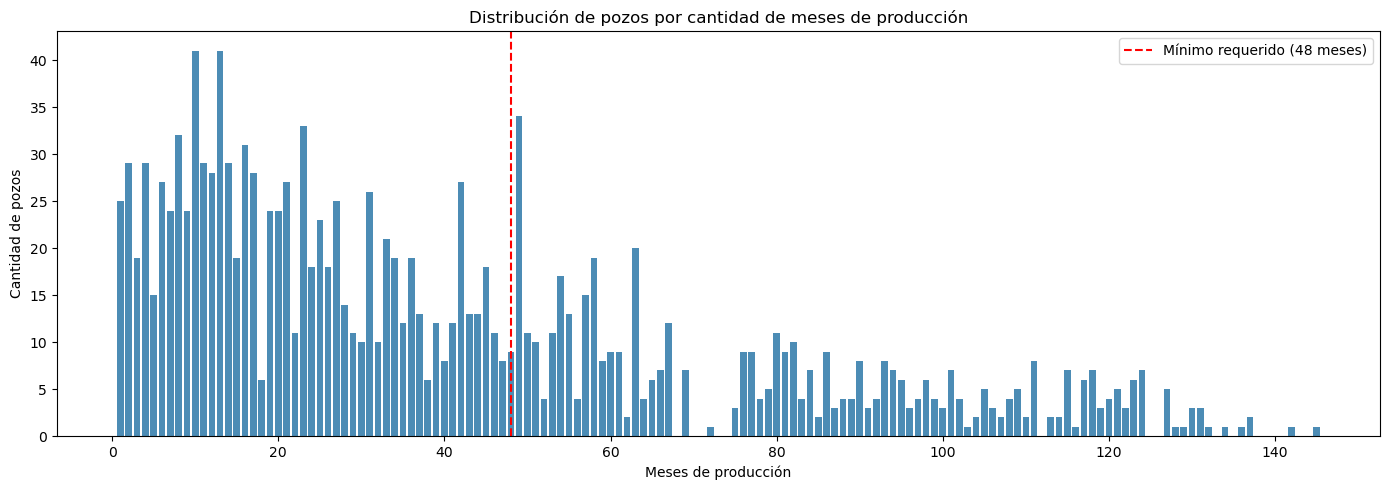

In [26]:
# ══════════════════════════════════════════════════════════════════
# 3.1) Filtro de longitud mínima de historia
# ══════════════════════════════════════════════════════════════════
# Cada pozo necesita suficientes meses de producción para poder armar una
# ventana de entrada + el horizonte de forecast de 12 meses. Umbral simple
# (sin lógica de continuidad/huecos por ahora — se revisa en 3.2 si hace falta).

MESES_MINIMOS = 48  # 36 meses de ventana de entrada + 12 de horizonte de forecast

meses_por_pozo = df.groupby("idpozo").size().rename("meses_produccion")

print(f"Pozos totales: {meses_por_pozo.shape[0]:>6,}")
print(meses_por_pozo.describe())

# Distribución de pozos por cantidad de meses de producción
meses_dist = meses_por_pozo.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(meses_dist.index, meses_dist.values, width=0.8, color="#4C8CB5")
ax.axvline(MESES_MINIMOS, color="red", linestyle="--", linewidth=1.5,
           label=f"Mínimo requerido ({MESES_MINIMOS} meses)")
ax.set_xlabel("Meses de producción")
ax.set_ylabel("Cantidad de pozos")
ax.set_title("Distribución de pozos por cantidad de meses de producción")
ax.legend()
plt.tight_layout()
plt.show()


 meses_minimos  pozos_retenidos  pct_retenido
            12             1165          79.8
            18              989          67.8
            24              864          59.2
            30              755          51.7
            36              657          45.0
            42              587          40.2
            48              497          34.1
            54              418          28.6
            60              342          23.4
            72              266          18.2
            84              201          13.8


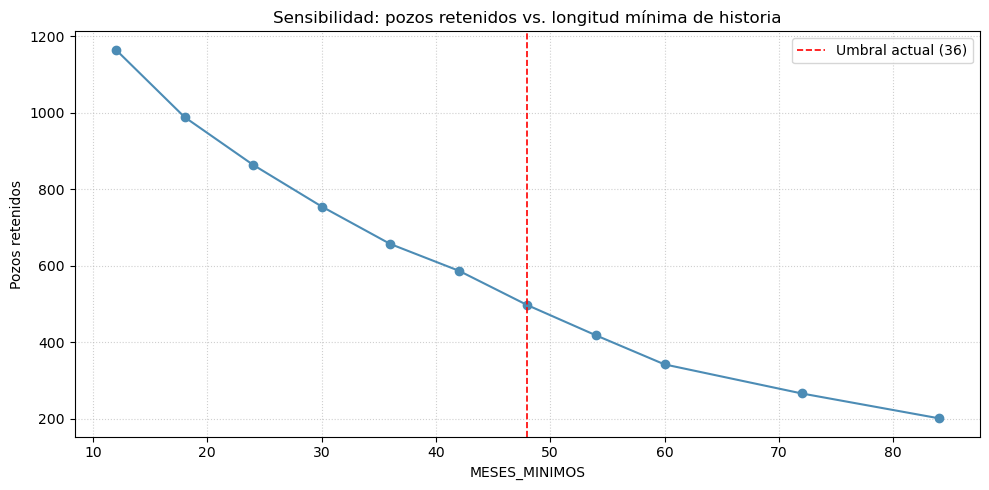

In [27]:
# ── Sensibilidad: pozos retenidos según MESES_MINIMOS ───────────────────────

umbrales = [12, 18, 24, 30, 36, 42, 48, 54, 60, 72, 84]

sensibilidad = pd.DataFrame({
    "meses_minimos": umbrales,
    "pozos_retenidos": [(meses_por_pozo >= u).sum() for u in umbrales],
})
sensibilidad["pct_retenido"] = (sensibilidad["pozos_retenidos"] / len(meses_por_pozo) * 100).round(1)

print(sensibilidad.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sensibilidad["meses_minimos"], sensibilidad["pozos_retenidos"], marker="o", color="#4C8CB5")
ax.axvline(MESES_MINIMOS, color="red", linestyle="--", linewidth=1.2, label="Umbral actual (36)")
ax.set_xlabel("MESES_MINIMOS")
ax.set_ylabel("Pozos retenidos")
ax.set_title("Sensibilidad: pozos retenidos vs. longitud mínima de historia")
ax.legend()
ax.grid(linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


In [28]:

# ── Evaluar el filtro (todavía no se aplica sobre df) ───────────────────────
pozos_validos = meses_por_pozo[meses_por_pozo >= MESES_MINIMOS].index

pozos_antes = df["idpozo"].nunique()
pozos_descartados = pozos_antes - len(pozos_validos)

print(f"\nPozos antes del filtro de longitud mínima   : {pozos_antes:>6,}")
print(f"Pozos con menos de {MESES_MINIMOS} meses de historia : {pozos_descartados:>6,}")
print(f"Pozos que quedarían después del filtro      : {len(pozos_validos):>6,}")
print("\n`df` todavía no fue modificado")



Pozos antes del filtro de longitud mínima   :  1,459
Pozos con menos de 48 meses de historia :    962
Pozos que quedarían después del filtro      :    497

`df` todavía no fue modificado


#### 3.1) Cortes de calendario y elegibilidad de pozos por split

Se invocan las funciones de `datasets.py` para 
- derivar los cortes de calendario fijos de Train/Val/Test a partir de la hipótesis de ventana (36 meses de input, 12 de target, mínimo 12 ventanas deslizantes en Train) 
- determinar, pozo por pozo, si su historia alcanza para cada split.

`elegibilidad_pozos()` devuelve un dataframe indexado por `idpozo`, con:
-  `fecha_min` (el primer mes con registro de producción de ese pozo) y `fecha_max` (el último mes con registro)
- tres columnas booleanas — `elegible_train`, `elegible_val`, `elegible_test` que indican, para cada pozo, a qué split(s) puede aportar ventanas bajo estos criterios (no todos los pozos califican para los tres).

**Decisión**: se avanza con estos criterios que implican que habrá 205 pozos para Train que sigue siendo un volumen razonable de ejemplos de entrenamiento (205 pozos × 12+ ventanas cada uno)


In [29]:
from datasets import calcular_cortes_split, elegibilidad_pozos

cortes = calcular_cortes_split(df, input_len=36, target_len=12, min_ventanas_train=12)

print(f"Mes más reciente en df: {cortes.fecha_max}")
print(f"\nTEST  → input {cortes.test_input_start} a {cortes.test_target_start - 1}   |  target {cortes.test_target_start} a {cortes.fecha_max}")
print(f"VAL   → input {cortes.val_input_start} a {cortes.val_target_start - 1}   |  target {cortes.val_target_start} a {cortes.test_target_start - 1}")
print(f"TRAIN → rango {cortes.train_start} a {cortes.train_target_max_end}")

resumen_pozo = elegibilidad_pozos(df, cortes)

print(f"\nPozos totales                       : {len(resumen_pozo):>6,}")
print(f"Elegibles para TRAIN                : {resumen_pozo['elegible_train'].sum():>6,}  ({resumen_pozo['elegible_train'].mean()*100:.1f}%)")
print(f"Elegibles para VAL                   : {resumen_pozo['elegible_val'].sum():>6,}  ({resumen_pozo['elegible_val'].mean()*100:.1f}%)")
print(f"Elegibles para TEST                  : {resumen_pozo['elegible_test'].sum():>6,}  ({resumen_pozo['elegible_test'].mean()*100:.1f}%)")

display(resumen_pozo)


Mes más reciente en df: 2026-05

TEST  → input 2022-06 a 2025-05   |  target 2025-06 a 2026-05
VAL   → input 2021-06 a 2024-05   |  target 2024-06 a 2025-05
TRAIN → rango 2019-07 a 2024-05

Pozos totales                       :  1,459
Elegibles para TRAIN                :    205  (14.1%)
Elegibles para VAL                   :    342  (23.4%)
Elegibles para TEST                  :    497  (34.1%)


,fecha_min,fecha_max,elegible_train,elegible_val,elegible_test
idpozo,,,,,
147488,2014-05,2026-05,True,True,True
152993,2014-08,2026-05,True,True,True
153620,2015-01,2026-05,True,True,True
153622,2015-01,2026-05,True,True,True
153773,2015-02,2026-05,True,True,True
...,...,...,...,...,...
167320,2026-05,2026-05,False,False,False
167321,2026-05,2026-05,False,False,False
167322,2026-05,2026-05,False,False,False


#### 3.2) Descarte final y guardado de datos con variables candidatas

Se descartan los pozos que no califican para ningún split (ni Train, ni Val, ni Test) — ya no aportan nada al pipeline. El `df` resultante se guarda en `datos_modelo.csv`. 

Como un chequeo del desarrollo, se valida que el archivo guardado reproduce los mismos valores: 
- Se lee el archivo guardado en disco (`datos_modelo.csv`) en `df_aux`
- Se recalculan nuevamente los cortes de calendario y la elegibilidad de pozos. 
- Como se puede observar, las cantidades elegibles para train/val/test calculadas sobre `df_aux`, son iguales a las cantidades reportadas en la celda anterior (205, 342 y 497 para train/val/test)

In [30]:
# ── Eliminar pozos sin historia mínima para ningún split ────────────────────

pozos_utiles = resumen_pozo[
    resumen_pozo["elegible_train"] | resumen_pozo["elegible_val"] | resumen_pozo["elegible_test"]
].index

pozos_antes = df["idpozo"].nunique()
df = df[df["idpozo"].isin(pozos_utiles)].copy()
pozos_despues = df["idpozo"].nunique()

print(f"Pozos antes de descartar sin historia mínima        : {pozos_antes:>6,}")
print(f"Pozos descartados (no elegibles para ningún split)  : {pozos_antes - pozos_despues:>6,}")
print(f"Pozos después                                       : {pozos_despues:>6,}")

# ── Guardar el dataset final ─────────────────────────────────────────────────
df.to_csv("datos_modelo.csv", index=False)
print(f"\nGuardado 'datos_modelo.csv' ({len(df):,} filas, {df['idpozo'].nunique():,} pozos)")

# ── Releer desde disco y repetir TODA la lógica (cortes + elegibilidad) ─────
# para validar de punta a punta que el CSV guardado reproduce lo mismo.
df_aux = pd.read_csv("datos_modelo.csv")

cortes_aux = calcular_cortes_split(df_aux, input_len=36, target_len=12, min_ventanas_train=12)
resumen_pozo_aux = elegibilidad_pozos(df_aux, cortes_aux)

print(f"\n[Validación releyendo 'datos_modelo.csv']")
print(f"Mes más reciente en df_aux: {cortes_aux.fecha_max}")
print(f"Pozos totales                       : {len(resumen_pozo_aux):>6,}")
print(f"Elegibles para TRAIN                : {resumen_pozo_aux['elegible_train'].sum():>6,}  ({resumen_pozo_aux['elegible_train'].mean()*100:.1f}%)")
print(f"Elegibles para VAL                   : {resumen_pozo_aux['elegible_val'].sum():>6,}  ({resumen_pozo_aux['elegible_val'].mean()*100:.1f}%)")
print(f"Elegibles para TEST                  : {resumen_pozo_aux['elegible_test'].sum():>6,}  ({resumen_pozo_aux['elegible_test'].mean()*100:.1f}%)")


Pozos antes de descartar sin historia mínima        :  1,459
Pozos descartados (no elegibles para ningún split)  :    962
Pozos después                                       :    497

Guardado 'datos_modelo.csv' (39,562 filas, 497 pozos)

[Validación releyendo 'datos_modelo.csv']
Mes más reciente en df_aux: 2026-05
Pozos totales                       :    497
Elegibles para TRAIN                :    205  (41.2%)
Elegibles para VAL                   :    342  (68.8%)
Elegibles para TEST                  :    497  (100.0%)


## 4) Visualización de Series de producción

A continuación se realizarán las siguientes visualizaciones:


- Se toman al azar 4 pozos, 2 con la menor y 2 con la mayor cantidad de meses transcurridos desde su primer registro de producción, mostrando la serie completa (incluyendo meses en cero)
- Se toman al azar otros 4 pozos, uno por cada cuartil considerando la producción promedio de los últimos 12 meses, para ver la diversidad de niveles de producción del universo.


C:\Users\ignsagul\AppData\Local\Temp\ipykernel_31520\3654443729.py:4: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  periodo = pd.PeriodIndex(year=df["anio_prod"], month=df["mes_prod"], freq="M")


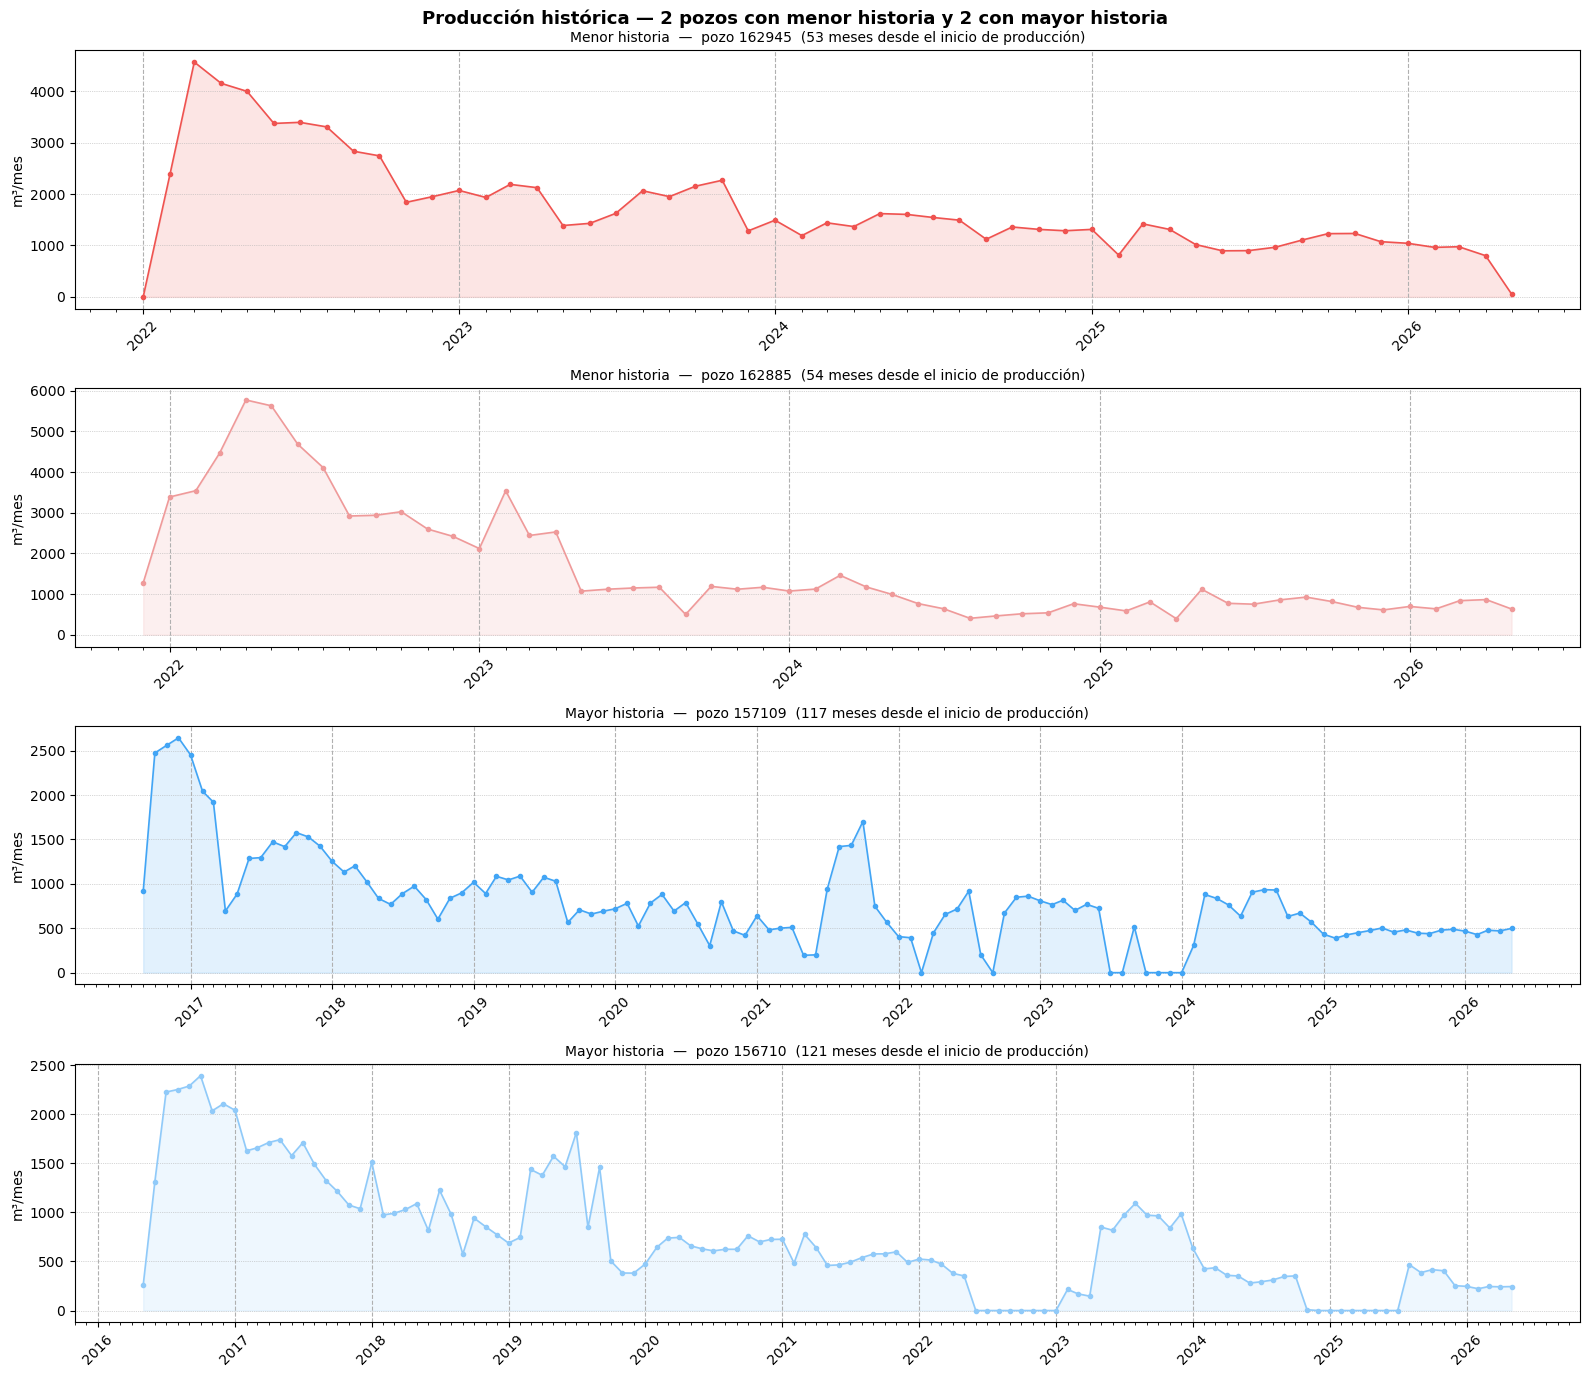

In [31]:
import matplotlib.dates as mdates

# ── Meses de historia por pozo: desde el primer hasta el último mes con registro ──
periodo = pd.PeriodIndex(year=df["anio_prod"], month=df["mes_prod"], freq="M")
resumen_fechas = (
    df.assign(periodo=periodo)
    .groupby("idpozo")["periodo"]
    .agg(fecha_min="min", fecha_max="max")
    .reset_index()
)
resumen_fechas["meses_historia"] = (
    resumen_fechas["fecha_max"].apply(lambda p: p.ordinal)
    - resumen_fechas["fecha_min"].apply(lambda p: p.ordinal)
    + 1
)

p25 = resumen_fechas["meses_historia"].quantile(0.25)
p75 = resumen_fechas["meses_historia"].quantile(0.75)

pozos_menos_historia = resumen_fechas[resumen_fechas["meses_historia"] <= p25]
pozos_mas_historia = resumen_fechas[resumen_fechas["meses_historia"] >= p75]

RANDOM_STATE = 42   # cambiar para obtener distintos pozos

muestra_menos = pozos_menos_historia.sample(2, random_state=RANDOM_STATE)
muestra_mas = pozos_mas_historia.sample(2, random_state=RANDOM_STATE)

pozos_muestra = (
    [("Menor historia", row["idpozo"], row["meses_historia"]) for _, row in muestra_menos.iterrows()] +
    [("Mayor historia", row["idpozo"], row["meses_historia"]) for _, row in muestra_mas.iterrows()]
)

# ── Figura 4 subplots verticales (serie completa, con ceros incluidos) ──────
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=False)
fig.suptitle("Producción histórica — 2 pozos con menor historia y 2 con mayor historia", fontsize=13, fontweight="bold")

colors = ["#EF5350", "#EF9A9A", "#42A5F5", "#90CAF9"]

for ax, (label, idpozo, meses), color in zip(axes, pozos_muestra, colors):
    datos = (df[df["idpozo"] == idpozo]
             .sort_values(["anio_prod", "mes_prod"])
             .copy())
    datos["fecha"] = pd.to_datetime(
        datos[["anio_prod", "mes_prod"]].assign(day=1)
        .rename(columns={"anio_prod": "year", "mes_prod": "month"})
    )

    ax.plot(datos["fecha"], datos["prod_pet"],
            color=color, marker="o", markersize=3, linewidth=1.2)
    ax.fill_between(datos["fecha"], datos["prod_pet"], alpha=0.15, color=color)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.grid(axis="x", which="major", linestyle="--", linewidth=0.8)
    ax.grid(axis="y", linestyle=":", linewidth=0.5)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("m³/mes")
    ax.set_title(
        f"{label}  —  pozo {idpozo}  ({meses:.0f} meses desde el inicio de producción)",
        fontsize=10
    )

plt.tight_layout()
plt.show()


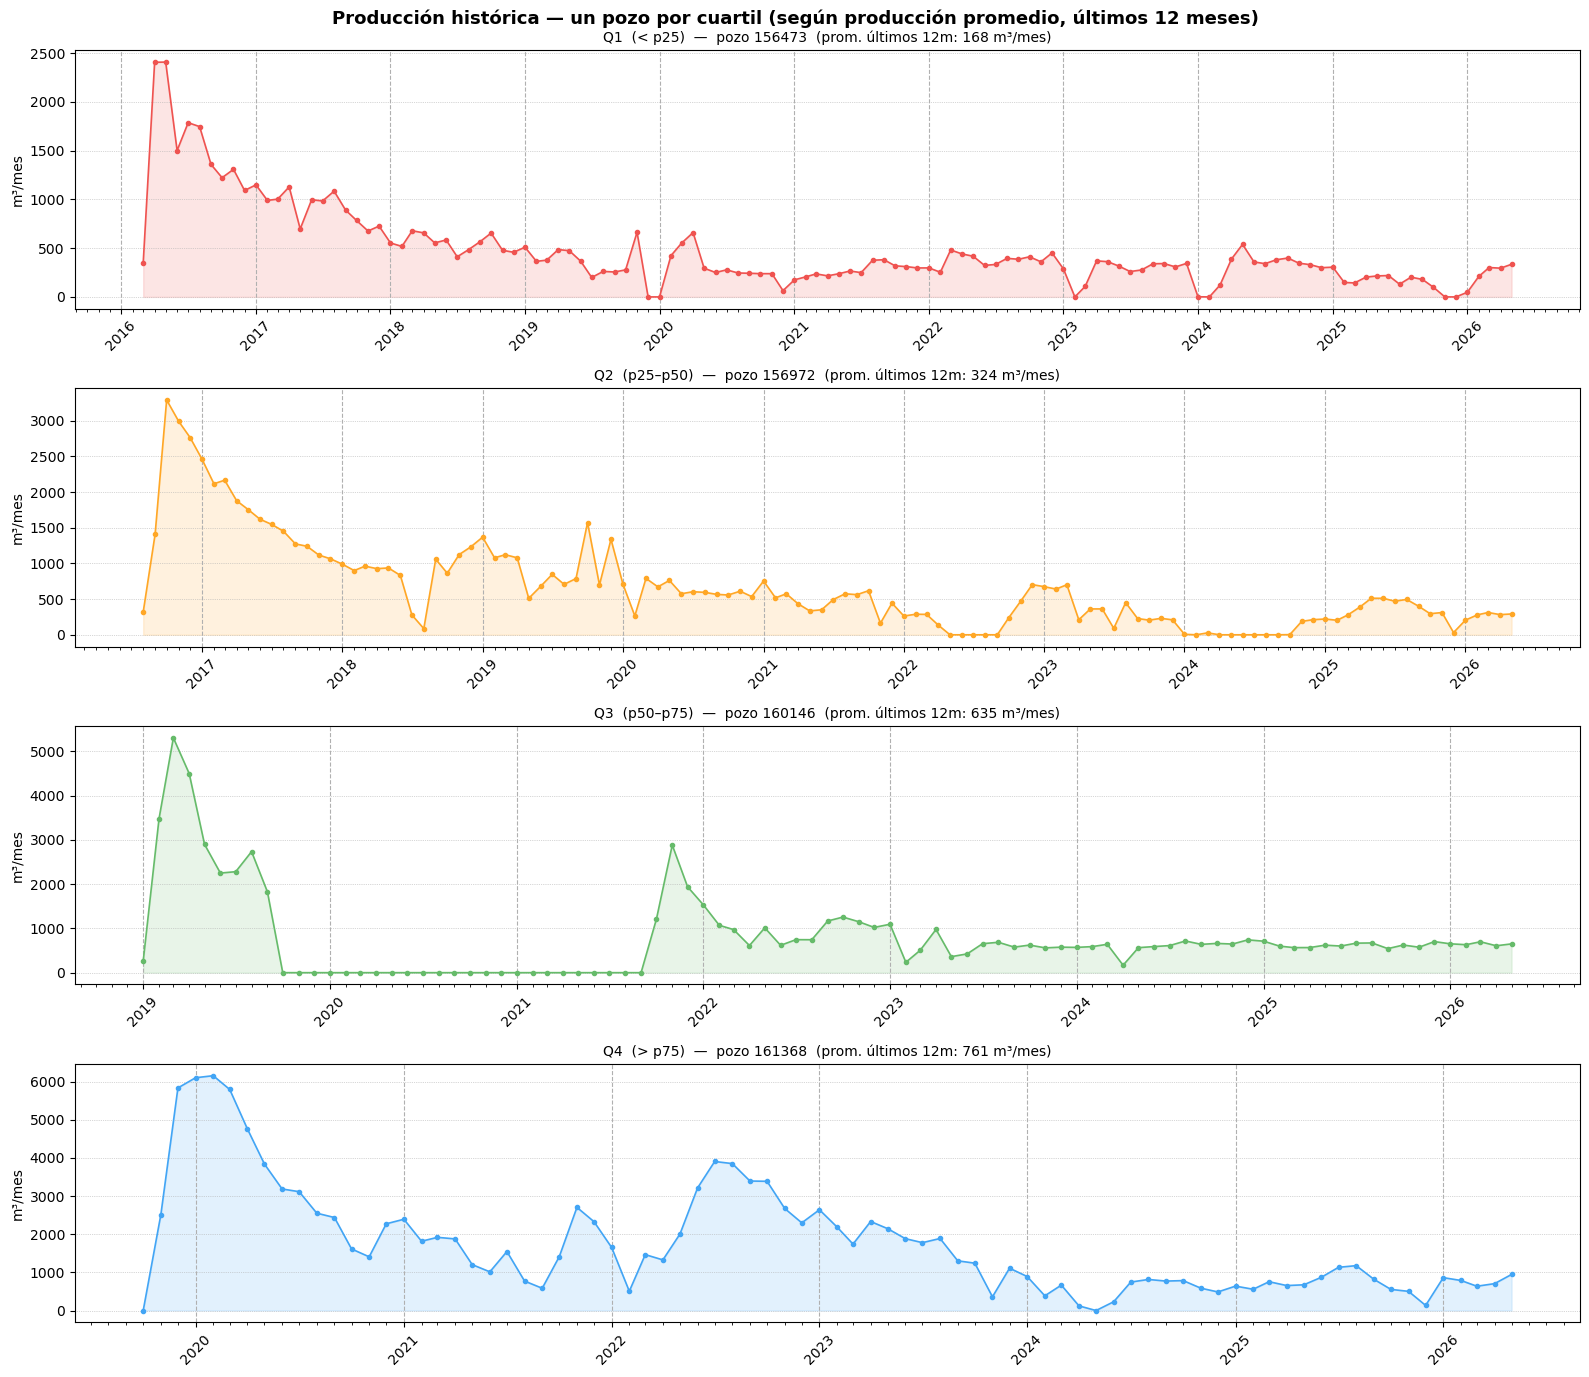

In [32]:
import matplotlib.dates as mdates

# ── Producción promedio de los últimos 12 meses por pozo ─────────────────────
prod_ultimos_12m = (
    df.sort_values(["idpozo", "anio_prod", "mes_prod"])
    .groupby("idpozo")
    .tail(12)
    .groupby("idpozo")["prod_pet"]
    .mean()
    .rename("prod_prom_12m")
    .reset_index()
)

# ── Cuartiles y selección aleatoria (random_state fijo → reproducible) ──────
p25 = prod_ultimos_12m["prod_prom_12m"].quantile(0.25)
p50 = prod_ultimos_12m["prod_prom_12m"].quantile(0.50)
p75 = prod_ultimos_12m["prod_prom_12m"].quantile(0.75)

cuartiles = [
    ("Q1  (< p25)",   prod_ultimos_12m[prod_ultimos_12m["prod_prom_12m"] <  p25]),
    ("Q2  (p25–p50)", prod_ultimos_12m[(prod_ultimos_12m["prod_prom_12m"] >= p25) & (prod_ultimos_12m["prod_prom_12m"] <  p50)]),
    ("Q3  (p50–p75)", prod_ultimos_12m[(prod_ultimos_12m["prod_prom_12m"] >= p50) & (prod_ultimos_12m["prod_prom_12m"] <  p75)]),
    ("Q4  (> p75)",   prod_ultimos_12m[prod_ultimos_12m["prod_prom_12m"] >= p75]),
]

RANDOM_STATE = 42   # cambiar para obtener distintos pozos

pozos_muestra = [
    (label, grp.sample(1, random_state=RANDOM_STATE)["idpozo"].iloc[0])
    for label, grp in cuartiles
]

# ── Figura 4 subplots verticales ──────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=False)
fig.suptitle("Producción histórica — un pozo por cuartil (según producción promedio, últimos 12 meses)", fontsize=13, fontweight="bold")

colors = ["#EF5350", "#FFA726", "#66BB6A", "#42A5F5"]

for ax, (label, idpozo), color in zip(axes, pozos_muestra, colors):
    datos = (df[df["idpozo"] == idpozo]
             .sort_values(["anio_prod", "mes_prod"])
             .copy())
    datos["fecha"] = pd.to_datetime(
        datos[["anio_prod", "mes_prod"]].assign(day=1)
        .rename(columns={"anio_prod": "year", "mes_prod": "month"})
    )
    prod_prom = prod_ultimos_12m.loc[prod_ultimos_12m["idpozo"] == idpozo, "prod_prom_12m"].iloc[0]

    ax.plot(datos["fecha"], datos["prod_pet"],
            color=color, marker="o", markersize=3, linewidth=1.2)
    ax.fill_between(datos["fecha"], datos["prod_pet"], alpha=0.15, color=color)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.grid(axis="x", which="major", linestyle="--", linewidth=0.8)
    ax.grid(axis="y", linestyle=":", linewidth=0.5)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("m³/mes")
    ax.set_title(
        f"{label}  —  pozo {idpozo}  (prom. últimos 12m: {prod_prom:,.0f} m³/mes)",
        fontsize=10
    )

plt.tight_layout()
plt.show()


## 5) Análisis de la variable target (prod_pet)

Se realizan dos análisis sobre `prod_pet`: comparación de histogramas (crudo vs. `log1p`) y heterogeneidad de escala entre pozos.

- **Histogramas `prod_pet` crudo vs. `log1p`**: la distribución cruda es fuertemente asimétrica; `log1p` la acerca a una forma simétrica y manejable.
- **Heterogeneidad de escala entre pozos**: la producción promedio (últimos 12 meses) varía mucho entre pozos — al ser un modelo único compartido, esto exige normalizar también por pozo, ya que `log1p` comprime la diferencia de escala pero no la elimina.

**Implicancias para la normalización**: `prod_pet` no puede alimentarse al modelo en su escala cruda. Se aplican dos transformaciones, en este orden: **`log1p`** primero, y luego **normalización por pozo** (media/desvío del pozo, sobre los valores ya en escala log) — normalizar antes de `log1p` generaría valores negativos fuera de su dominio. Esto se desarrolla en  `datasets.py`/`test_datasets.ipynb`.


####  5.1) Histogramas `prod_pet` crudo vs. `log1p`

Observaciones

- **`prod_pet` (crudo)**: distribución fuertemente asimétrica hacia la derecha — un pico cercano a cero (~9.000 registros) y una cola larga y decreciente que se extiende hasta más de 15.000 m³/mes.
- **`log1p(prod_pet)`**: la parte positiva de la distribución se acerca a una forma simétrica tipo campana, centrada alrededor de 6-7 — confirma que la transformación logarítmica corrige la asimetría. Sin embargo, aparece un pico separado en `x = 0` (~2.800 registros), que no es parte de esa campana sino una masa puntual aparte: corresponde a los meses con producción exactamente nula (`prod_pet = 0`), analizados en la siguiente sección.


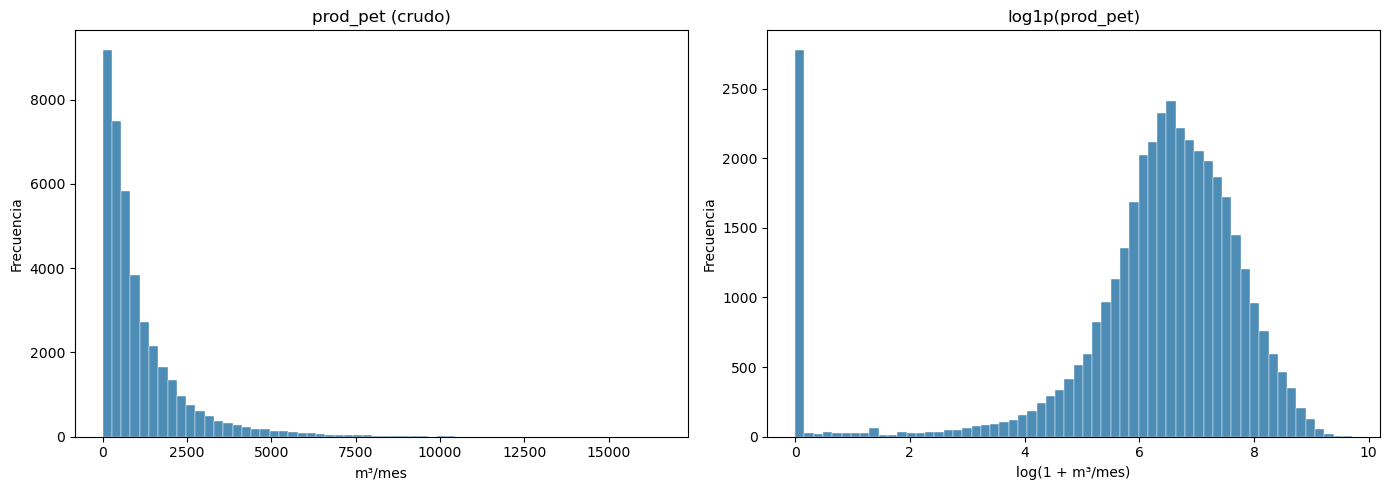

In [33]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["prod_pet"], bins=60, color="#4C8CB5", edgecolor="white", linewidth=0.3)
axes[0].set_title("prod_pet (crudo)")
axes[0].set_xlabel("m³/mes")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(df["prod_pet"]), bins=60, color="#4C8CB5", edgecolor="white", linewidth=0.3)
axes[1].set_title("log1p(prod_pet)")
axes[1].set_xlabel("log(1 + m³/mes)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


#### 5.2) Heterogeneidad de escala entre pozos (prod. promedio, últimos 12 meses) 

count     497.000000
mean      564.097241
std       400.327922
min         3.222988
25%       292.607500
50%       478.450000
75%       729.713333
max      2706.400000
Name: prod_prom_12m, dtype: float64

Pozo más productivo   :    2,706.4 m³/mes
Pozo menos productivo :        3.2 m³/mes
Razón máximo/mínimo   :        840x


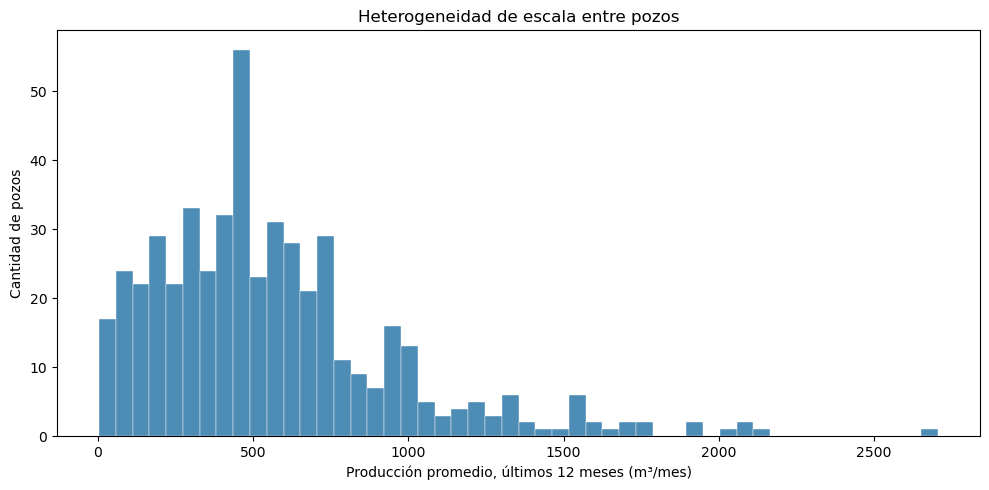

In [34]:

prod_prom_12m = (
    df.sort_values(["idpozo", "anio_prod", "mes_prod"])
    .groupby("idpozo")
    .tail(12)
    .groupby("idpozo")["prod_pet"]
    .mean()
    .rename("prod_prom_12m")
)

print(prod_prom_12m.describe())

# Se excluyen pozos con promedio 0 (pozo parado en toda la ventana reciente)
# del cálculo de la razón, para no dividir por cero / no distorsionar con un
# caso que no representa "escala productiva" sino inactividad puntual.
prod_positiva = prod_prom_12m[prod_prom_12m > 0]
razon_max_min = prod_positiva.max() / prod_positiva.min()

print(f"\nPozo más productivo   : {prod_positiva.max():>10,.1f} m³/mes")
print(f"Pozo menos productivo : {prod_positiva.min():>10,.1f} m³/mes")
print(f"Razón máximo/mínimo   : {razon_max_min:>10,.0f}x")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(prod_prom_12m, bins=50, color="#4C8CB5", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Producción promedio, últimos 12 meses (m³/mes)")
ax.set_ylabel("Cantidad de pozos")
ax.set_title("Heterogeneidad de escala entre pozos")
plt.tight_layout()
plt.show()


#### 5.3) Análisis de meses con prod_pet = 0

En el histograma de `log1p(prod_pet)` se observó una masa puntual en `x = 0` (~2.800 registros) — meses con producción nula. Durante este análisis se encontró que `df_prod` trae el atributo **`tipoestado`** a nivel mensual (a diferencia de `df_pozos`, que solo tiene una foto estática), indicando el estado operativo del pozo cada mes (`Extracción Efectiva`, `Parado Transitoriamente`, `En Reparación`, `Abandonado`, etc.).

**Solución para este TP**: se incorpora un flag binario **`activo`** (`tipoestado_prod == "Extracción Efectiva"`) como regresor **histórico** (varía mes a mes en la ventana de entrada) — ayuda al modelo a distinguir un cero administrativo de un cero de declive real. 

La producción nula afecta al 6,9% de los registros y al 75,5% de los pozos, pero el 89,8% de esos casos queda explicado por `tipoestado_prod` (mayormente `Parado Transitoriamente`).



In [35]:
# ── ¿Qué peso tienen los meses con prod_pet == 0? ────────────────────────────

n_total = len(df)
n_cero = (df["prod_pet"] == 0).sum()

print(f"Registros totales (pozo-mes)      : {n_total:>8,}")
print(f"Registros con prod_pet == 0       : {n_cero:>8,}  ({n_cero/n_total*100:.1f}%)")

pozos_con_algun_cero = df.loc[df["prod_pet"] == 0, "idpozo"].nunique()
pozos_totales = df["idpozo"].nunique()

print(f"\nPozos con al menos 1 mes en cero  : {pozos_con_algun_cero:>8,}  ({pozos_con_algun_cero/pozos_totales*100:.1f}% de {pozos_totales:,} pozos)")

# Distribución de cuántos meses en cero tiene cada pozo afectado
ceros_por_pozo = df[df["prod_pet"] == 0].groupby("idpozo").size()
print(f"\nMeses en cero por pozo afectado (solo pozos con >=1 cero):")
print(ceros_por_pozo.describe())

Registros totales (pozo-mes)      :   39,562
Registros con prod_pet == 0       :    2,746  (6.9%)

Pozos con al menos 1 mes en cero  :      375  (75.5% de 497 pozos)

Meses en cero por pozo afectado (solo pozos con >=1 cero):
count    375.000000
mean       7.322667
std        8.547752
min        1.000000
25%        1.000000
50%        4.000000
75%       10.000000
max       52.000000
dtype: float64


In [36]:
# ── ¿tipoestado_prod explica los meses con producción en 0? ─────────────────
# fillna primero para que los nulos aparezcan como categoría propia en la
# tabla, en vez de que pd.crosstab los descarte en silencio (era la causa
# del desajuste entre la tabla y el resumen).
estado = df["tipoestado_prod"].fillna("(sin dato)")

tabla = pd.crosstab(estado, df["prod_pet"] == 0, margins=True, margins_name="Total")
tabla.columns = ["prod_pet > 0", "prod_pet == 0", "Total"]
tabla["pct_en_cero"] = (tabla["prod_pet == 0"] / tabla["Total"] * 100).round(1)

print(tabla.sort_values("pct_en_cero", ascending=False).to_string())

# ── Meses en cero, separados en 3 grupos ─────────────────────────────────────
ceros_estado = estado[df["prod_pet"] == 0]

n_total = len(ceros_estado)
n_explicado = ((ceros_estado != "Extracción Efectiva") & (ceros_estado != "(sin dato)")).sum()
n_desconocido = (ceros_estado == "(sin dato)").sum()
n_sin_explicar = (ceros_estado == "Extracción Efectiva").sum()

print(f"\nMeses en cero total                                 : {n_total:>6,}")
print(f"  Explicados por status documentado (!= Efectiva)   : {n_explicado:>6,}  ({n_explicado/n_total*100:.1f}%)")
print(f"  Estado desconocido (sin dato)                      : {n_desconocido:>6,}  ({n_desconocido/n_total*100:.1f}%)")
print(f"  Sin explicar (Extracción Efectiva pero en cero)    : {n_sin_explicar:>6,}  ({n_sin_explicar/n_total*100:.1f}%)")


                          prod_pet > 0  prod_pet == 0  Total  pct_en_cero
tipoestado_prod                                                          
(sin dato)                           0            123    123        100.0
Abandonado                           0             28     28        100.0
En Espera de Reparación              0             15     15        100.0
En Reserva de Gas                    0              2      2        100.0
Parado Transitoriamente            115           2339   2454         95.3
Otras Situación Inactivo            15             65     80         81.2
En Estudio                           5              5     10         50.0
Otras Situación Activo              58             13     71         18.3
Total                            36816           2746  39562          6.9
Extracción Efectiva              36623            156  36779          0.4

Meses en cero total                                 :  2,746
  Explicados por status documentado (!= Efectiva) 

## 6) Análisis de variables regresoras

Se analiza la distribución de las variables regresoras para decidir cómo normalizarlas antes de pasarlas al modelo. Al ser un modelo único compartido entre pozos con escalas muy distintas, no pueden usarse en su escala cruda.

**Normalización a aplicar, según lo observado:**

- **`log1p` + estandarizar** (asimetría fuerte, masa concentrada en cero — mismo patrón que `prod_pet`): `arena_bombeada_importada_tn`.
- **Estandarizar directo** (distribución razonable, sin necesidad de transformación previa): `profundidad_pozo`, `longitud_rama_horizontal_m`, `cantidad_fracturas`, `arena_bombeada_nacional_tn`, `agua_inyectada_m3`, `presion_maxima_psi`, `coordenadax`, `coordenaday`.

`longitud_rama_horizontal_m` y `cantidad_fracturas` muestran una distribución bimodal (dos "generaciones" de diseño de completación) — no es asimetría que `log1p` resuelva, así que se estandarizan directo igual que el resto de este grupo.



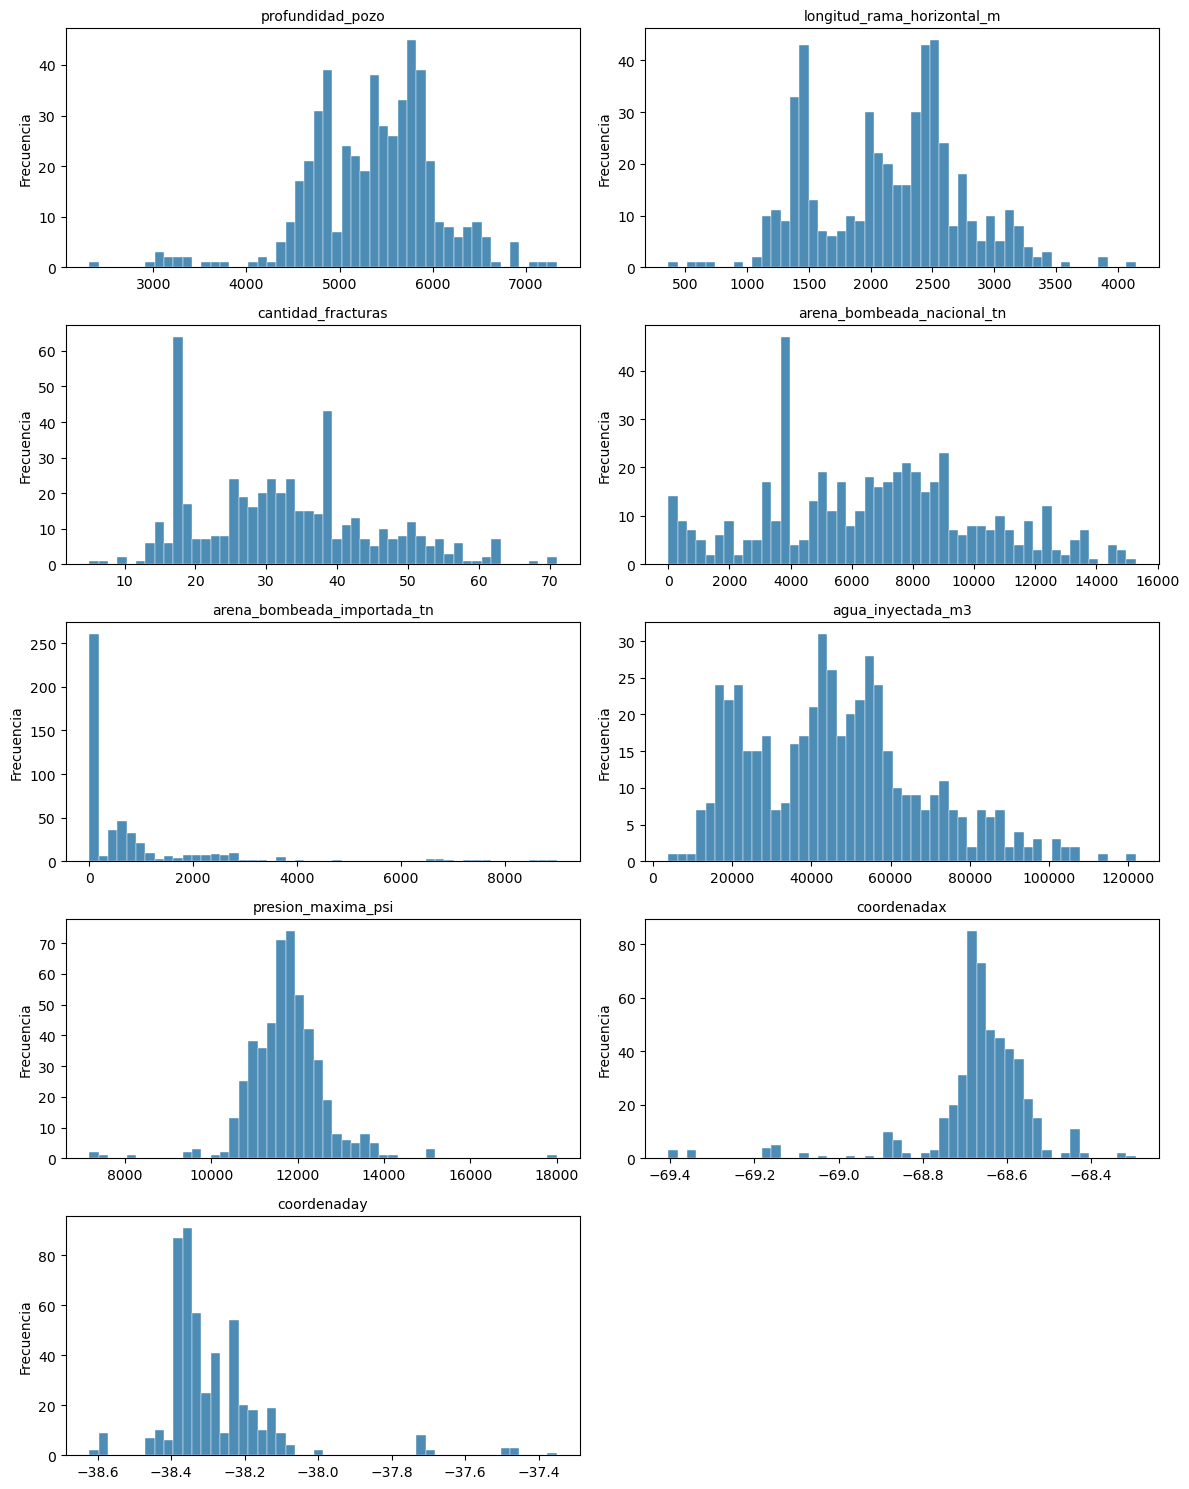

In [37]:
import matplotlib.pyplot as plt

# Estáticas (1 valor por pozo, repetido en cada fila mensual) — se usa 1 fila
# por pozo para no distorsionar la forma según cuántos meses tiene cada uno.
cols_estaticas = [
    "profundidad_pozo", "longitud_rama_horizontal_m", "cantidad_fracturas",
    "arena_bombeada_nacional_tn", "arena_bombeada_importada_tn", "agua_inyectada_m3",
    "presion_maxima_psi", "coordenadax", "coordenaday",
]

df_pozo_unico = df.drop_duplicates(subset="idpozo")

n_cols = 2
n_rows = -(-len(cols_estaticas) // n_cols)  # división hacia arriba

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cols_estaticas):
    ax.hist(df_pozo_unico[col].dropna(), bins=50, color="#4C8CB5", edgecolor="white", linewidth=0.3)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Frecuencia")

# Apagar subplots sobrantes si cols_estaticas no llena la grilla
for ax in axes[len(cols_estaticas):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
